# Analiza uticaja razvoja tehnologija veštačke inteligencije i kriptovaluta na cene grafičkih karti

## Autori
* Maja Varga R2 5/2024
* Nikola Simić E2 17/2024

## Sadržaj
1. Eksplorativna analiza uticaja karakteristika grafičkih karti na profitabilnost kopanja kriptovalute
2. Eksplorativna analiza uticaja karakteristika grafičkih karti na performanse AI treniranja
3. Timeseries analiza i predikcija cene grafičkih karti na osnovu spoljašnjih fakotora kao što su cene kriptovaluta Monero, Ethereum Classic i trenda AI treniranja

## **PRVI DEO**: Eksplorativna analiza uticaja karakteristika grafičkih karti na profitabilnost kopanja kriptovalute
### UVOD
Cilj prvog dela ove analize je pronalazak ključnih karakteristika grafičkih karti koje utiču na profitabilnost kopanja kriptovalute. Na osnovu analize će biti izdvojene najbitnije karakteristike grafičkih karti, uz pomoć kojih će se izvršiti predikcija profitabilnosti za sve ostale karte. Razmatrane kriptovalute su *Monero* kao predstavnik valute koja se kopa algoritmima koji primarno koriste procesorsku moć (*core-intensive*) i *Ethereum Classic* kao predstavnik valute koja se kopa algoritmima koji primarno koriste memoriju (*memory-intensive*).

### Biblioteke koje se koriste:

In [69]:
import os, glob
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from pathlib import Path
from rapidfuzz import process, fuzz
from scipy.stats import pearsonr, spearmanr, f_oneway
import matplotlib.pyplot as plt
import seaborn as sns
import re
from io import StringIO
import warnings
import matplotlib.dates as mdates
import statsmodels.api as sm
import pmdarima as pm
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Ne prikazivati Jupyther upozorenja, radi preglednosti
warnings.filterwarnings('ignore')

2025-10-27 21:54:58.466927: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-27 21:54:58.467120: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-27 21:54:58.490102: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-27 21:54:59.452140: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

### Pomoćne funkcije koje se koriste:

In [4]:
# Za numeričke podatke koji imaju sufikse ili prefikse (GB, Mhz itd.) koje samo treba parsirati u float
def extract_float(value):
    if pd.isna(value):
        return None
    match = re.search(r'[\d.]+', str(value))
    return float(match.group()) if match else None


# Za konverziju iz float-a u int
def extract_int(value):
    n = extract_float(value)
    if n is not None:
        return int(n)
    else:
        return None

# Slično extract_float funkciji, ali menja string koji se parsira
def to_num(x):
    if isinstance(x, str):
        x = re.sub(r'[^0-9.\-]', '', x)
    try:
        return float(x)
    except:
        return None

# Za uklanjanje znakova $ iz kolone cene i vraćanje konvertovane cene u float
def clean_currency(value):
    if pd.isna(value):
        return None
    cleaned = re.sub(r'[^0-9\.\-]', '', str(value))
    try:
        return float(cleaned)
    except ValueError:
        return None
    
# Za uklanjanje oznake cloud infrastrukture na kojoj su pokrenuti algoritmi za kopanje
def clean_gpu_name(name: str) -> str:
    remove_words = ['lambdacloud', '1x']
    if pd.isna(name):
        return None
    name = name.lower()
    pattern = r'\b(?:' + '|'.join(remove_words) + r')\b'
    name = re.sub(pattern, '', name)
    name = re.sub(r'[^a-z0-9 ]', ' ', name)
    name = re.sub(r'\s+', ' ', name).strip()
    name = re.sub(r"\s*\([^)]*\)", "", name).strip()
    name = re.sub(r"\b(LHR|FULL\s*UNLOCK|ENGINEERING SAMPLE)\b", "", name, flags=re.IGNORECASE)
    name = re.sub(r'(\d+)(gb)', r'\1 \2', name, flags=re.IGNORECASE)
    name = name.strip()
    return name

# Formatiranje datuma na Mesec Godina format, npr. Oct 2025
def format_date(value):
    if pd.isna(value):
        return None        
    try:
        dt = pd.to_datetime(value, errors='coerce')
        if pd.isna(dt):
            return value
        return dt.strftime("%b %Y")
    except Exception:
        return None

# Konverzija MB u KB (vezano za keš memoriju)
def mb_to_kb(value):
    if pd.isna(value):
        return None
    s = str(value).strip()
    match_mb = re.match(r'([\d\.]+)\s*MB', s, re.I)
    if match_mb:
        return float(match_mb[1]) * 1024

    match_kb = re.match(r'([\d\.]+)\s*KB', s, re.I)
    if match_kb:
        return float(match_kb[1])
    
    return None

# Konverzija GB u MB (vezano za memoriju)
def gb_to_mb(value):
    if pd.isna(value):
        return None
    s = str(value).strip()
    match_mb = re.match(r'([\d\.]+)\s*MB', s, re.I)
    if match_mb:
        return float(match_mb[1])
    match = re.match(r'([\d\.]+)\s*GB', str(value), re.I)
    if match:
        return float(match[1]) * 1024
    return None


# Konverzija TB/s u GB/s (vezano za Bandwidth)
def tb_to_gb(value):
    if pd.isna(value):
        return None
    s = str(value).strip()
    match_gb = re.match(r'([\d\.]+)\s*GB/s', s, re.I)
    if match_gb:
        return float(match_gb[1])
    match = re.match(r'([\d\.]+)\s*TB/s', str(value), re.I)
    if match:
        return float(match[1]) * 1024
    return None

# Konverzija TFLOPS u GFLOPS (vezano za broj floating-point operacija po sekundi)
def tf_to_gf(value):
    if pd.isna(value):
        return None
    s = str(value).replace(',', '').strip()

    match = re.match(r'([\d\.]+)\s*GFLOPS', s, re.I)
    if match:
        return float(match[1])
    match = re.match(r'([\d\.]+)\s*TFLOPS', str(value), re.I)
    if match:
        return float(match[1]) * 1000
    return value

Podaci koji se koriste se nalaze na putanji:

In [5]:
# DATA_DIR = Path("D:/Fax/I semestar/Sistemi za istraživanje i analizu podataka/Projekat/consumer-gpu-price-analysis/data")
DATA_DIR = Path("./data")

### Osnovni podaci o grafičkim kartama

**Napomena**: Pošto su podaci scrape-ovani sa Interneta, postoje greške u formatiranju koje zahtevaju predprocesiranje samih podataka. CSV fajl u kome se nalaze prikupljeni podaci izgleda ovako:

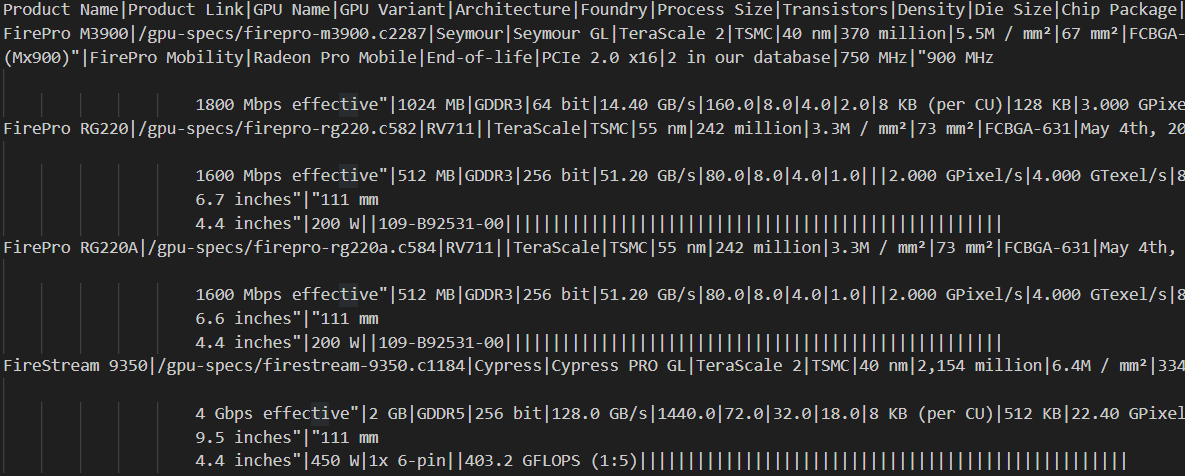

Dakle, potrebno je prvo spojiti razdvojene redove kako bi se dalje analizirali podaci. Nakon ovog predprocesiranja, podaci izgledaju ovako:

In [6]:
with open(f"{DATA_DIR}/gpu-details.csv", "r", encoding="utf-8", errors="ignore") as f:
        raw = f.read()
raw_fixed = re.sub(r'"([^"]*)"', lambda m: m.group(0).replace('\n', ' '), raw)
raw_fixed = raw_fixed.replace('"', '')
raw_fixed = re.sub(r'[ \t]+', ' ', raw_fixed)
df_gpu = pd.read_csv(StringIO(raw_fixed), sep='|')
df_gpu

,Product Name,Product Link,GPU Name,GPU Variant,Architecture,Foundry,Process Size,Transistors,Density,Die Size,...,Pixel Shader,Vertex Shader,SMX Count,SMM Count,Tensor Cores,BF16,TF32,FP64 Tensor,NVENC,NVDEC
0,FirePro M3900,/gpu-specs/firepro-m3900.c2287,Seymour,Seymour GL,TeraScale 2,TSMC,40 nm,370 million,5.5M / mm²,67 mm²,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FirePro RG220,/gpu-specs/firepro-rg220.c582,RV711,NaN,TeraScale,TSMC,55 nm,242 million,3.3M / mm²,73 mm²,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FirePro RG220A,/gpu-specs/firepro-rg220a.c584,RV711,NaN,TeraScale,TSMC,55 nm,242 million,3.3M / mm²,73 mm²,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,FireStream 9350,/gpu-specs/firestream-9350.c1184,Cypress,Cypress PRO GL,TeraScale 2,TSMC,40 nm,"2,154 million",6.4M / mm²,334 mm²,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,FireStream 9370,/gpu-specs/firestream-9370.c1185,Cypress,Cypress XT GL,TeraScale 2,TSMC,40 nm,"2,154 million",6.4M / mm²,334 mm²,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1747,RTX PRO 5000 Blackwell,/gpu-specs/rtx-pro-5000-blackwell.c4276,GB202,NaN,Blackwell 2.0,TSMC,5 nm,"92,200 million",122.9M / mm²,750 mm²,...,NaN,NaN,NaN,NaN,440.0,NaN,NaN,NaN,NaN,NaN
1748,RTX PRO 6000 Blackwell,/gpu-specs/rtx-pro-6000-blackwell.c4272,GB202,NaN,Blackwell 2.0,TSMC,5 nm,"92,200 million",122.9M / mm²,750 mm²,...,NaN,NaN,NaN,NaN,752.0,NaN,NaN,NaN,NaN,NaN
1749,RTX PRO 6000 Blackwell Max-Q,/gpu-specs/rtx-pro-6000-blackwell-max-q.c4273,GB202,NaN,Blackwell 2.0,TSMC,5 nm,"92,200 million",122.9M / mm²,750 mm²,...,NaN,NaN,NaN,NaN,752.0,NaN,NaN,NaN,NaN,NaN
1750,RTX PRO 6000 Blackwell Server,/gpu-specs/rtx-pro-6000-blackwell-server.c4274,GB202,NaN,Blackwell 2.0,TSMC,5 nm,"92,200 million",122.9M / mm²,750 mm²,...,NaN,NaN,NaN,NaN,752.0,NaN,NaN,NaN,NaN,NaN


Postoje **1752** grafičke karte u skupu podataka sa **98** obeležja. Od svih obeležja, odabrana su sledeća koja su relevantna za izradu projektnog zadatka, a koja predstavljaju osnovne karakteristike grafičkih karti:
*Product Name, Base Clock, Boost Clock, Memory Clock, Memory Size, Memory Type, Memory Bus, Bandwidth, TDP, L1 Cache, L2 Cache, Shading Units, FP32 (float), Tensor Cores, Matrix Cores*.

- ***Product Name***: Naziv grafičke karte koji identifikuje model i proizvođača.

- ***Base Clock***: Osnovna radna frekvencija GPU-a u MHz koja određuje brzinu obrade podataka u normalnom režimu (numeričko obeležje).

- ***Boost Clock***: Maksimalna frekvencija GPU-a koju može dostići pri zahtevnim zadacima za bolje performanse (numeričko obeležje).

- ***Memory Clock***: Brzina memorije grafičke karte koja utiče na brzinu čitanja i pisanja podataka (numeričko obeležje).

- ***Memory Size***: Ukupna količina grafičke memorije (VRAM) koja omogućava skladištenje tekstura i podataka za obradu (numeričko obeležje).

- ***Memory Type***: Tip memorije (npr. GDDR6, HBM2) koji utiče na performanse i efikasnost memorijskog sistema (kategoričko obeležje).

- ***Memory Bus***: Širina memorijskog interfejsa u bitovima koja određuje koliko podataka GPU može istovremeno preneti (numeričko obeležje).

- ***Bandwidth***: Maksimalna količina podataka koju memorija može preneti po sekundi (numeričko obeležje).

- ***TDP***: *Thermal Design Power*, odnosno maksimalna potrošnja energije GPU-a u vatima (numeričko obeležje).

- ***L1 Cache***: Mali, brzi interni keš u GPU-u koji ubrzava pristup često korišćenim podacima (numeričko obeležje).

- ***L2 Cache***: Veća keš memorija koji služi za smanjenje kašnjenja pri čitanju podataka iz VRAM-a (numeričko obeležje).

- ***Shading Units***: Broj procesora (*CUDA processor* za *Nvidia*-u ili *Stream processor* za *AMD*) za paralelnu obradu grafičkih i računarskih zadataka (numeričko obeležje).

- ***FP32 (float)***: Teorijska snaga GPU-a u single-precision (32-bit) floating point operacijama izražena u FLOPS (FLOP operacija po sekundi) (numeričko obeležje).

- ***Tensor Cores***: Specijalizovani procesori za ubrzanje operacija veštačke inteligencije i dubokog učenja.

- ***Matrix Cores***: Specijalizovani procesori za brze matriksne operacije, često korišćene u AI zadacima.

Izdvojene podatke je potrebno predprocesirati, kako bi se svi sveli na istu jedinicu - konkretno, potrebno je *Memory Size* svesti na megabajte, *Bandwidth* na gigabajte, *L1 Cache* i *L2 Cache* na kilobajte i *FP32 (float)* na gigaflopove (GFLOPS). Ime modela bi trebalo normalizovati da sadrži samo ključne reči (proizvođač, oznaka modela, broj serije i dodatne oznake poput Ti, Super, gigabajti RAM memorije), a za ostala polja ekstrahovati numeričku vrednost (odbaciti prefikse ili sufikse). Nakon ovog koraka, podaci o grafičkim kartama izgledaju ovako:

In [7]:
relevant_columns = [
    "Product Name",
    "Base Clock", "Boost Clock",
    "Memory Clock", "Memory Size", "Memory Type", "Memory Bus", "Bandwidth",
    "TDP", "L1 Cache", "L2 Cache",
    "Shading Units", "FP32 (float)", "Tensor Cores", 'Matrix Cores']
df_gpu = df_gpu[relevant_columns]
df_gpu['Product Name'] = df_gpu['Product Name'].apply(clean_gpu_name)
df_gpu['Base Clock'] = df_gpu['Base Clock'].apply(extract_float)
df_gpu['Boost Clock'] = df_gpu['Boost Clock'].apply(extract_float)
df_gpu['Memory Clock'] = df_gpu['Memory Clock'].apply(extract_float)
df_gpu['Memory Size'] = df_gpu['Memory Size'].apply(gb_to_mb)
df_gpu['Memory Bus'] = df_gpu['Memory Bus'].apply(extract_int)
df_gpu['Memory Type'] = df_gpu['Memory Type'].str.strip()
df_gpu['Bandwidth'] = df_gpu['Bandwidth'].apply(tb_to_gb)

df_gpu['TDP'] = df_gpu['TDP'].apply(extract_float)
df_gpu['L1 Cache'] = df_gpu['L1 Cache'].apply(mb_to_kb)
df_gpu['L2 Cache'] = df_gpu['L2 Cache'].apply(mb_to_kb)
df_gpu['Shading Units'] = df_gpu['Shading Units'].apply(extract_int)
df_gpu['FP32 (float)'] = df_gpu['FP32 (float)'].apply(tf_to_gf)
df_gpu['Tensor Cores'] = df_gpu['Tensor Cores'].apply(extract_int)
df_gpu['Matrix Cores'] = df_gpu['Matrix Cores'].apply(extract_int)
df_gpu

,Product Name,Base Clock,Boost Clock,Memory Clock,Memory Size,Memory Type,Memory Bus,Bandwidth,TDP,L1 Cache,L2 Cache,Shading Units,FP32 (float),Tensor Cores,Matrix Cores
0,firepro m3900,NaN,NaN,900.0,1024.0,GDDR3,64.0,14.40,20.0,8.0,128.0,160.0,240.0,NaN,NaN
1,firepro rg220,NaN,NaN,800.0,512.0,GDDR3,256.0,51.20,35.0,NaN,NaN,80.0,80.0,NaN,NaN
2,firepro rg220a,NaN,NaN,800.0,512.0,GDDR3,256.0,51.20,35.0,NaN,NaN,80.0,80.0,NaN,NaN
3,firestream 9350,NaN,NaN,1000.0,2048.0,GDDR5,256.0,128.00,150.0,8.0,512.0,1440.0,2016.0,NaN,NaN
4,firestream 9370,NaN,NaN,1150.0,4096.0,GDDR5,256.0,147.20,225.0,8.0,512.0,1600.0,2640.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1747,rtx pro 5000 blackwell,1590.0,2617.0,1750.0,49152.0,GDDR7,384.0,1372.16,300.0,128.0,98304.0,14080.0,73690.0,440.0,NaN
1748,rtx pro 6000 blackwell,1590.0,2617.0,1750.0,98304.0,GDDR7,512.0,1832.96,600.0,128.0,131072.0,24064.0,126000.0,752.0,NaN
1749,rtx pro 6000 blackwell max q,1590.0,2288.0,1750.0,98304.0,GDDR7,512.0,1832.96,300.0,128.0,131072.0,24064.0,110100.0,752.0,NaN
1750,rtx pro 6000 blackwell server,1590.0,2617.0,1750.0,98304.0,GDDR7,512.0,1832.96,600.0,128.0,131072.0,24064.0,126000.0,752.0,NaN


In [8]:
df_gpu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product Name   1752 non-null   object 
 1   Base Clock     1091 non-null   float64
 2   Boost Clock    1091 non-null   float64
 3   Memory Clock   1569 non-null   float64
 4   Memory Size    1569 non-null   float64
 5   Memory Type    1752 non-null   object 
 6   Memory Bus     1569 non-null   float64
 7   Bandwidth      1569 non-null   float64
 8   TDP            1609 non-null   float64
 9   L1 Cache       1493 non-null   float64
 10  L2 Cache       1580 non-null   float64
 11  Shading Units  1746 non-null   float64
 12  FP32 (float)   1746 non-null   float64
 13  Tensor Cores   286 non-null    float64
 14  Matrix Cores   19 non-null     float64
dtypes: float64(13), object(2)
memory usage: 205.4+ KB


Samo *Product Name* i *Memory Type* su zabeleženi za sve grafičke karte - procena nedostajućih vrednosti će biti urađena za sva ostala polja. 

U nastavku slede posebne analize za *Monero* i *Ethereum Classic* kriptovalute.
### Monero

#### Skup podataka sa kojim se radi:

**Napomena**: Pošto su podaci scrape-ovani sa Interneta, postoje greške u formatiranju koje zahtevaju predprocesiranje samih podataka. CSV fajl u kome se nalaze prikupljeni podaci izgleda ovako:

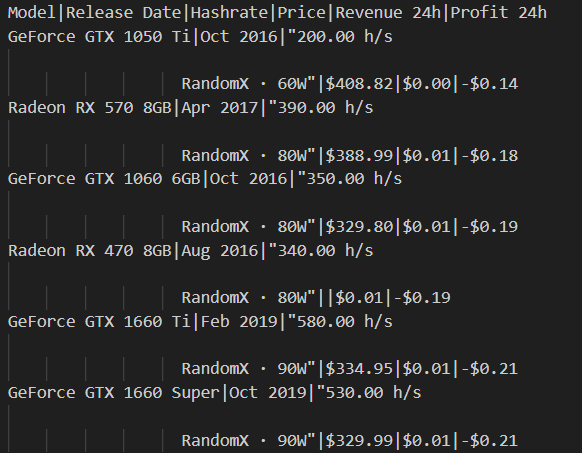

Dakle, potrebno je spojiti redove koji su podeljeni na više redova i izvući *hashrate* u jedinici h/s, izbaciti specifikaciju algoritma koji se koristi (RandomX), normalizovati ime modela da sadrži samo ključne reči (proizvođač, oznaka modela, broj serije i dodatne oznake poput Ti, Super, gigabajti RAM memorije) i ekstrahovati zaradu (posmatramo ***Revenue 24h*** kao ciljno obeležje, s obzirom na to da *Profit 24h* uzima u obzir i troškove struje koja je potrebna za kopanje kriptovaluti, što je relativna informacija koja varira u odnosu na region i način snabdevanja). Funkcija koja će izvršiti potrebno predprocesiranje je sledeća:

In [9]:
def clean_mining_csv(file_path: str) -> pd.DataFrame:
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        raw = f.read()
    raw_fixed = re.sub(r'"([^"]*)"', lambda m: m.group(0).replace('\n', ' '), raw)
    raw_fixed = raw_fixed.replace('"', '')
    raw_fixed = re.sub(r'RandomX\s*·\s*', '', raw_fixed, flags=re.IGNORECASE)
    raw_fixed = re.sub(r'[ \t]+', ' ', raw_fixed)
    df = pd.read_csv(StringIO(raw_fixed), sep='|')

    for col in df.columns:
        df[col] = df[col].astype(str).str.strip()

    df['Model'] = df['Model'].apply(clean_gpu_name)
    df = df.drop_duplicates(subset=["Model"], keep="first")
    
    df['Hashrate'] = df['Hashrate'].str.replace(
        r'(\d+(?:\.\d+)?)\s*[kK]\s*h/s',
        lambda m: str(float(m.group(1)) * 1000) + ' h/s',
        regex=True
    )

    df['Hashrate'] = df['Hashrate'].str.replace(
        r'(\d+(?:\.\d+)?)\s*[mM]\s*h/s',
        lambda m: str(float(m.group(1)) * 1000000) + ' h/s',
        regex=True
    )

    df['Hashrate'] = df['Hashrate'].str.extract(r'([\d.]+)').astype(float)

    df['Revenue 24h'] = df['Revenue 24h'].apply(clean_currency)

    return df[['Model', 'Hashrate', 'Revenue 24h']]

Podaci koji se dobiju nakon predprocesiranja izgledaju ovako:

In [10]:
df_mining = clean_mining_csv(f"{DATA_DIR}/mining-gpus-101-xmr-randomx.csv")
df_mining

,Model,Hashrate,Revenue 24h
0,geforce gtx 1050 ti,200.0,0.00
1,radeon rx 570 8 gb,390.0,0.01
2,geforce gtx 1060 6 gb,350.0,0.01
3,radeon rx 470 8 gb,340.0,0.01
4,geforce gtx 1660 ti,580.0,0.01
5,geforce gtx 1660 super,530.0,0.01
6,geforce gtx 1660,530.0,0.01
7,radeon rx 480 8 gb,470.0,0.01
8,radeon rx 580 8 gb,470.0,0.01
9,geforce rtx 2060,600.0,0.01


In [11]:
df_mining.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23 entries, 0 to 24
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Model        23 non-null     object 
 1   Hashrate     23 non-null     float64
 2   Revenue 24h  23 non-null     float64
dtypes: float64(2), object(1)
memory usage: 736.0+ bytes


- ***Model*** – Naziv i varijanta grafičke karte koja definiše njen tip i arhitekturu.

- ***Hashrate*** – Brzina kojom grafička karta izvršava kriptografske proračune tokom rudarenja izražena u h/s.

- ***Revenue 24h*** – Procenjena zarada koju ta grafička karta ostvari u toku 24 sata rudarenja izražena u dolarima (**bez uračunatih troškova struje**).

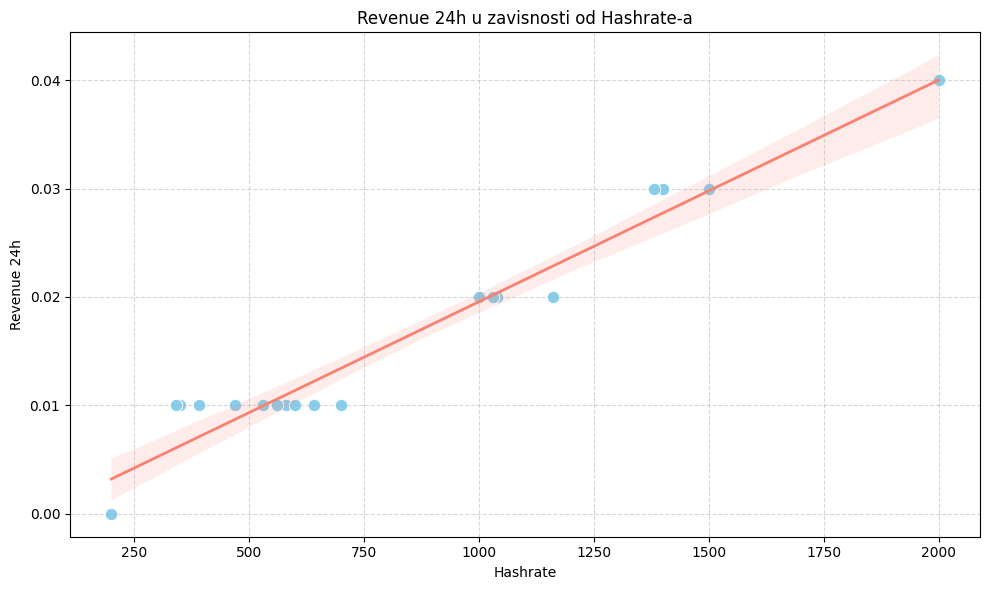

In [12]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df_mining, x='Hashrate', y='Revenue 24h', color='skyblue', s=80)

sns.regplot(data=df_mining, x='Hashrate', y='Revenue 24h', scatter=False, color='salmon', line_kws={"linewidth":2})

plt.xlabel("Hashrate")
plt.ylabel("Revenue 24h")
plt.title("Revenue 24h u zavisnosti od Hashrate-a")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Vizuelnom analizom podataka se može pretpostaviti da se povećanjem *hashrate*-a povećava i zarada. 

In [13]:
pearson_corr, pearson_p = pearsonr(df_mining['Hashrate'], df_mining['Revenue 24h'])
print(f"Pirsonov koeficijent: {pearson_corr}. Relevantno obeležje: {pearson_p < 0.05}")

Pirsonov koeficijent: 0.9732874931736512. Relevantno obeležje: True


Pirsonov koeficijent pokazuje da je odnos između povećanja *hashrate*-a i zarade skoro linearan - zato možemo ukloniti *hashrate* iz razmatranih karakteristika GPU-a, jer znamo kakav odnos ima na konačnu zaradu.

In [14]:
df_mining = df_mining[['Model', 'Revenue 24h']]

Podaci o specifikaciji grafičke karte i o profitabilnosti kopanja su preuzeti sa različitih sajtova - postoje manja odstupanja u imenovanju modela grafičke karte. Kako je za dalju analizu potrebno da se ova dva skupa podataka spoje u jedan jedinstveni (u kome će samo mali broj imati zabeležen *Revenue 24h*), iskoristićemo *fuzzy* poklapanje stringova. Podaci nakon spajanja izgledaju ovako:

In [15]:
def fuzzy_merge(df_mining: pd.DataFrame, df_gpu: pd.DataFrame, threshold=85, is_ai = False) -> pd.DataFrame:
    df_mining = df_mining.copy()
    df_gpu = df_gpu.copy()
    target_attr = 'Revenue 24h'
    if is_ai:
        target_attr = 'Speedup'

    df_gpu[target_attr] = pd.NA

    gpu_names = df_gpu["Product Name"].tolist()

    for _, mining_row in df_mining.iterrows():
        mining_name = mining_row["Model"]
        
        best_match = process.extractOne(
            mining_name, 
            gpu_names, 
            scorer=fuzz.ratio
        )
    
        if best_match:
            matched_name, score, index = best_match
            if score >= threshold:
                print(f"{mining_name} <=> {matched_name} (%: {score})")
                df_gpu.at[index, target_attr] = mining_row[target_attr]
    df_gpu[target_attr] = pd.to_numeric(df_gpu[target_attr], errors='coerce')
    return df_gpu

In [16]:
df_merged = fuzzy_merge(df_mining, df_gpu)
df_merged

geforce gtx 1050 ti <=> geforce gtx 1050 ti (%: 100.0)
radeon rx 570 8 gb <=> radeon rx 570 8 gb (%: 100.0)
geforce gtx 1060 6 gb <=> geforce gtx 1060 6 gb (%: 100.0)
radeon rx 470 8 gb <=> radeon rx 470 8 gb (%: 100.0)
geforce gtx 1660 ti <=> geforce gtx 1660 ti (%: 100.0)
geforce gtx 1660 super <=> geforce gtx 1660 super (%: 100.0)
geforce gtx 1660 <=> geforce gtx 1660 (%: 100.0)
radeon rx 480 8 gb <=> radeon rx 480 8 gb (%: 100.0)
radeon rx 580 8 gb <=> radeon rx 580 8 gb (%: 100.0)
geforce rtx 2060 <=> geforce rtx 2060 (%: 100.0)
geforce gtx 1080 <=> geforce gtx 1080 (%: 100.0)
geforce gtx 1070 ti <=> geforce gtx 1070 ti (%: 100.0)
geforce gtx 1070 <=> geforce gtx 1070 (%: 100.0)
geforce rtx 2070 <=> geforce rtx 2070 (%: 100.0)
radeon rx vega 56 <=> radeon rx vega 56 (%: 100.0)
geforce rtx 2080 <=> geforce rtx 2080 (%: 100.0)
radeon rx vega 64 <=> radeon rx vega 64 (%: 100.0)
geforce rtx 3070 <=> geforce rtx 3070 (%: 100.0)
geforce gtx 1080 ti <=> geforce gtx 1080 ti (%: 100.0)
rad

,Product Name,Base Clock,Boost Clock,Memory Clock,Memory Size,Memory Type,Memory Bus,Bandwidth,TDP,L1 Cache,L2 Cache,Shading Units,FP32 (float),Tensor Cores,Matrix Cores,Revenue 24h
0,firepro m3900,NaN,NaN,900.0,1024.0,GDDR3,64.0,14.40,20.0,8.0,128.0,160.0,240.0,NaN,NaN,NaN
1,firepro rg220,NaN,NaN,800.0,512.0,GDDR3,256.0,51.20,35.0,NaN,NaN,80.0,80.0,NaN,NaN,NaN
2,firepro rg220a,NaN,NaN,800.0,512.0,GDDR3,256.0,51.20,35.0,NaN,NaN,80.0,80.0,NaN,NaN,NaN
3,firestream 9350,NaN,NaN,1000.0,2048.0,GDDR5,256.0,128.00,150.0,8.0,512.0,1440.0,2016.0,NaN,NaN,NaN
4,firestream 9370,NaN,NaN,1150.0,4096.0,GDDR5,256.0,147.20,225.0,8.0,512.0,1600.0,2640.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1747,rtx pro 5000 blackwell,1590.0,2617.0,1750.0,49152.0,GDDR7,384.0,1372.16,300.0,128.0,98304.0,14080.0,73690.0,440.0,NaN,NaN
1748,rtx pro 6000 blackwell,1590.0,2617.0,1750.0,98304.0,GDDR7,512.0,1832.96,600.0,128.0,131072.0,24064.0,126000.0,752.0,NaN,NaN
1749,rtx pro 6000 blackwell max q,1590.0,2288.0,1750.0,98304.0,GDDR7,512.0,1832.96,300.0,128.0,131072.0,24064.0,110100.0,752.0,NaN,NaN
1750,rtx pro 6000 blackwell server,1590.0,2617.0,1750.0,98304.0,GDDR7,512.0,1832.96,600.0,128.0,131072.0,24064.0,126000.0,752.0,NaN,NaN


In [17]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product Name   1752 non-null   object 
 1   Base Clock     1091 non-null   float64
 2   Boost Clock    1091 non-null   float64
 3   Memory Clock   1569 non-null   float64
 4   Memory Size    1569 non-null   float64
 5   Memory Type    1752 non-null   object 
 6   Memory Bus     1569 non-null   float64
 7   Bandwidth      1569 non-null   float64
 8   TDP            1609 non-null   float64
 9   L1 Cache       1493 non-null   float64
 10  L2 Cache       1580 non-null   float64
 11  Shading Units  1746 non-null   float64
 12  FP32 (float)   1746 non-null   float64
 13  Tensor Cores   286 non-null    float64
 14  Matrix Cores   19 non-null     float64
 15  Revenue 24h    23 non-null     float64
dtypes: float64(14), object(2)
memory usage: 219.1+ KB


*Tensor Cores* i *Matrix Cores* su srodna imena za specijalizovana jezgra za izvršavanje računskih operacija u AI zadacima - razlika je samo u proizvođaču (za *Nvidia*-u su *Tensor Cores*, a za *AMD* su *Matrix Cores*). Potebno ih je spojiti u jednu jedinstvenu kolonu. <br>
**Napomena**: Za sve grafičke karte za koje nije naveden broj specijalizovanih jezgra se podrazumeva da ih nemaju.

In [18]:
def get_ai_cores(row):

    model = str(row.get("Product Name", "")).lower()

    if any(keyword in model for keyword in ["nvidia", "geforce", "gtx", "rtx", "titan",
                                             "tesla", "jetson", "quadro", "tegra", "nvs",
                                             "grid", "a100", "a40", "cmp","t500","a100x",
                                             "a10g", "a10", "a16", "a2", "a30", "a30x", "pg506-217",
                                             "pg506-232", "pg506-242", "t400", "t600", "a10m",
                                             "a800", "h100", "l40", "l40g", "l40s", "h800", "l20" 
                                             "b100", "b200"]):
        cores = row.get("Tensor Cores", 0)
        return 0 if pd.isna(cores) else cores
    
    elif any(keyword in model for keyword in ["amd", "radeon", "firepro", "firestream", "ryzen"]):
        cores = row.get("Matrix Cores", 0)
        return 0 if pd.isna(cores) else cores
      
    return 0

In [19]:
df_merged["AI Cores"] = df_merged.apply(get_ai_cores, axis=1)
df_merged = df_merged.drop(columns=["Tensor Cores", "Matrix Cores"], errors="ignore")
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product Name   1752 non-null   object 
 1   Base Clock     1091 non-null   float64
 2   Boost Clock    1091 non-null   float64
 3   Memory Clock   1569 non-null   float64
 4   Memory Size    1569 non-null   float64
 5   Memory Type    1752 non-null   object 
 6   Memory Bus     1569 non-null   float64
 7   Bandwidth      1569 non-null   float64
 8   TDP            1609 non-null   float64
 9   L1 Cache       1493 non-null   float64
 10  L2 Cache       1580 non-null   float64
 11  Shading Units  1746 non-null   float64
 12  FP32 (float)   1746 non-null   float64
 13  Revenue 24h    23 non-null     float64
 14  AI Cores       1752 non-null   float64
dtypes: float64(13), object(2)
memory usage: 205.4+ KB


Nedostajuće vrednosti atributa se moraju proceniti. Za potrebe procene atributa biće isprobana dva algoritma - ***Decision Tree*** i ***Random Forest***. Izračunaće se RMSE za oba algoritma, i odabrati onaj koji ima najmanju grešku za sve kolone za koje će se vršiti procena nedostajućih vrednosti. <br>
Želimo da uključimo i kategoričko obeležje *Memory Type* u kolone na osnovu kojih će se vrednosti procenjivati - to obeležje ćemo enkodirati *One Hot Encoder*-om.

In [20]:
def impute_numeric_columns(df: pd.DataFrame, target_attr = "Revenue 24h", random_state=42):
    df = df.copy()

    categorical_cols = ["Memory Type"]
    original_cats = df[categorical_cols].copy()

    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    encoded = encoder.fit_transform(df[categorical_cols])
    encoded_df = pd.DataFrame(
        encoded,
        columns=encoder.get_feature_names_out(categorical_cols),
        index=df.index
    )
    df = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1)

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if target_attr in numeric_cols:
        numeric_cols.remove(target_attr)

    models = {
        "DecisionTree": DecisionTreeRegressor(random_state=random_state),
        "RandomForest": RandomForestRegressor(n_estimators=200, random_state=random_state)
    }

    total_rmse = {name: 0 for name in models.keys()}
    column_scores = {}

    for col in numeric_cols:
        n_missing = df[col].isna().sum()
        if n_missing == 0:
            continue

        df_train = df[df[col].notna()]
        df_pred = df[df[col].isna()]

        features = [c for c in numeric_cols if c != col]

        X = df_train[features].fillna(df_train[features].median())
        y = df_train[col]
        X_pred = df_pred[features].fillna(df_train[features].median())

        X_tr, X_val, y_tr, y_val = train_test_split(
            X, y, test_size=0.2, random_state=random_state
        )

        scores = {}
        for name, model in models.items():
            model.fit(X_tr, y_tr)
            y_pred_val = model.predict(X_val)
            rmse = np.sqrt(root_mean_squared_error(y_val, y_pred_val))
            scores[name] = rmse
            total_rmse[name] += rmse
        print(f"Kolona: {col} -> RMSE: {scores}")
        column_scores[col] = scores

    best_model_name = min(total_rmse, key=total_rmse.get)
    best_model_class = models[best_model_name]

    print(f"Najbolji model: {best_model_name} (prema ukupnoj RMSE greški)")
    print(f"Ukupna RMSE greška: {total_rmse}")

    for col in numeric_cols:
        if df[col].isna().sum() == 0:
            continue

        df_train = df[df[col].notna()]
        df_pred = df[df[col].isna()]
        if df_pred.empty:
            continue

        features = [c for c in numeric_cols if c != col]
        X = df_train[features].fillna(df_train[features].median())
        y = df_train[col]
        X_pred = df_pred[features].fillna(df_train[features].median())

        best_model = best_model_class
        best_model.fit(X, y)
        df.loc[df[col].isna(), col] = best_model.predict(X_pred)

    for col in categorical_cols:
        df[col] = original_cats[col]

    encoded_cols = encoder.get_feature_names_out(categorical_cols)
    df.drop(columns=encoded_cols, inplace=True)

    return df

In [21]:
df_merged = impute_numeric_columns(df_merged)
df_merged.info()

Kolona: Base Clock -> RMSE: {'DecisionTree': np.float64(13.161772885675486), 'RandomForest': np.float64(11.95014961938803)}
Kolona: Boost Clock -> RMSE: {'DecisionTree': np.float64(14.997019236770738), 'RandomForest': np.float64(11.577964864120247)}
Kolona: Memory Clock -> RMSE: {'DecisionTree': np.float64(11.58027369799729), 'RandomForest': np.float64(10.175478297391265)}
Kolona: Memory Size -> RMSE: {'DecisionTree': np.float64(70.00234693125314), 'RandomForest': np.float64(66.53527026062048)}
Kolona: Memory Bus -> RMSE: {'DecisionTree': np.float64(4.845228390498942), 'RandomForest': np.float64(11.473764323817525)}
Kolona: Bandwidth -> RMSE: {'DecisionTree': np.float64(7.689297389458907), 'RandomForest': np.float64(9.459524408020544)}
Kolona: TDP -> RMSE: {'DecisionTree': np.float64(7.912468338580076), 'RandomForest': np.float64(6.435914510485754)}
Kolona: L1 Cache -> RMSE: {'DecisionTree': np.float64(3.791045743591963), 'RandomForest': np.float64(3.4649961293354994)}
Kolona: L2 Cache

Dakle, podaci su procenjeni *Random Forest* algoritmom koji je imao najmanju globalnu RMSE grešku. *Revenue 24h* se **ne procenjuje**, pošto predstavlja ciljnu promenljivu.

Sledeći korak je analiza uticaja svih karakteristika grafičkih karti na zaradu pri rudarenju. Cilj ovog koraka je izdvajanje najbitnijih obeležja koja će se koristiti za finalnu predikciju zarade za sve ostale grafičke karte za koje ovaj podatak ne postoji. <br>
Za analizu linearnih zavisnosti između karakteristika grafičkih karti i zarade koristiće se **Pirsonov** statistički test koji testira linearnu zavisnost između obeležja i **Spirmanov** test koji testira monotonu zavisnost između obeležja, pogodan za nelinearne zavisnosti. Za analizu zavisnosti između kategoričkog obeležja *Memory Type* i zarade koristiće se **ANOVA** statistički test.

In [22]:
def analyze_influence(df: pd.DataFrame, target_col="Revenue 24h"):
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != target_col]
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    categorical_cols = [c for c in categorical_cols if c != target_col]
    categorical_cols.remove('Product Name')
    results = []

    for col in numeric_cols:
        if df[col].nunique() > 1: 
            pearson_corr, pearson_p = pearsonr(df[col], df[target_col])
            spearman_corr, spearman_p = spearmanr(df[col], df[target_col])
            results.append({
                'attribute': col,
                'type': 'numeric',
                'pearson_corr': pearson_corr,
                'pearson_p': pearson_p,
                'spearman_corr': spearman_corr,
                'spearman_p': spearman_p,
            })

    for col in categorical_cols:
        groups = [group[target_col].values for name, group in df.groupby(col) if len(group) > 0]
        if len(groups) > 1:
            f_stat, p_value = f_oneway(*groups)
            results.append({
                'attribute': col,
                'type': 'categorical',
                'f_stat': f_stat,
                'p_value': p_value
            })

    numeric_results = sorted([r for r in results if r['type']=='numeric'], 
                             key=lambda x: abs(x['pearson_corr']), reverse=True)

    categorical_results = sorted([r for r in results if r['type']=='categorical'], 
                                 key=lambda x: x['p_value'])

    return numeric_results, categorical_results

In [23]:
numeric_res, categorical_res = analyze_influence(df_merged[df_merged['Revenue 24h'].notna()])
df_numeric_monero = pd.DataFrame(numeric_res)
df_categorical_monero = pd.DataFrame(categorical_res)
df_numeric_monero

,attribute,type,pearson_corr,pearson_p,spearman_corr,spearman_p
0,Bandwidth,numeric,0.918942,6.074052e-10,0.878594,3.517324e-08
1,TDP,numeric,0.903052,3.703867e-09,0.892249,1.069477e-08
2,L2 Cache,numeric,0.897371,6.563953e-09,0.865420,9.766584e-08
3,Shading Units,numeric,0.877651,3.798532e-08,0.887622,1.628302e-08
4,FP32 (float),numeric,0.872682,5.640160e-08,0.890483,1.258388e-08
5,Memory Size,numeric,0.837508,6.209868e-07,0.797131,5.280891e-06
6,Memory Clock,numeric,-0.575900,4.030832e-03,-0.629444,1.290451e-03
7,AI Cores,numeric,0.569826,4.532536e-03,0.523998,1.027458e-02
8,L1 Cache,numeric,0.446124,3.286296e-02,0.261640,2.278347e-01
9,Memory Bus,numeric,0.416886,4.781844e-02,0.819110,1.757305e-06


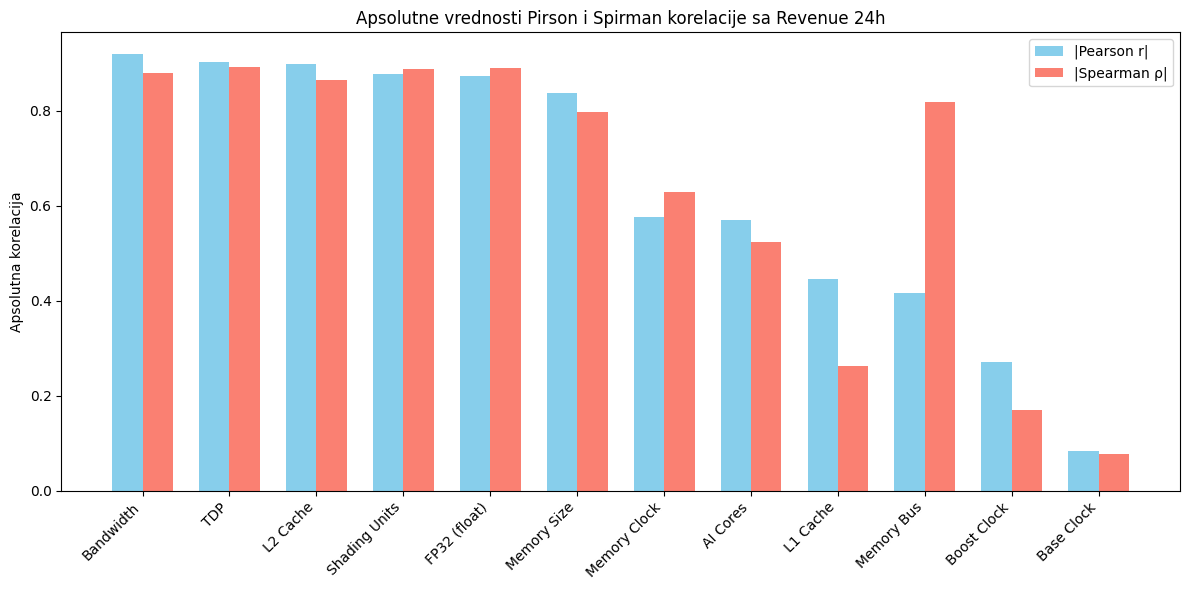

In [24]:
df_numeric_sorted = df_numeric_monero.sort_values(by='pearson_corr', key=abs, ascending=False)

plt.figure(figsize=(12,6))
bar_width = 0.35
index = range(len(df_numeric_sorted))

plt.bar(index, df_numeric_sorted['pearson_corr'].abs(), 
        bar_width, label='|Pearson r|', color='skyblue')

plt.bar([i + bar_width for i in index], df_numeric_sorted['spearman_corr'].abs(), 
        bar_width, label='|Spearman ρ|', color='salmon')


plt.xticks([i + bar_width/2 for i in index], df_numeric_sorted['attribute'], rotation=45, ha='right')
plt.ylabel("Apsolutna korelacija")
plt.title("Apsolutne vrednosti Pirson i Spirman korelacije sa Revenue 24h")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
df_categorical_monero

,attribute,type,f_stat,p_value
0,Memory Type,categorical,9.604788,0.000244


Prema rezultatima statističkih testova možemo zaključiti da su sva obeležja statistički značajna (**p vrednost za svako obeležje je manje od 0.05**). Posmatrajući rezultate testa za numerička obeležja, posebno se izdvaja jaka linearna korelacija između zarade i *TDP, Bandwidth, L2 Cache, Shading Units, FP32 (float)* i *Memory Size* obeležja. Ona će biti iskorišćena za finalnu predikciju zarade.<br>
Posmatrajući rezultate testa za kategoričko obeležje *Memory Type*, zaključuje se da je prosečna zarada u različitim grupama tipa memorije značajno različita, tj. da postoji jak uticaj tipa memorije na zaradu. Stoga, i ovo obeležje će biti iskorišćeno za finalnu predikciju zarade.

Krajnji korak je predikcija zarade u odnosu na izdvojena ključna obeležja (karakteristike) grafičkih karti. Za potrebu rešavanja ovog problema će biti iskorišćeni *Decision Tree* i *Random Forest* algoritmi, za koje će se računati RMSE i MAE greška. Odabraće se model koji ima najmanju grešku za obe metrike, i njime će se napraviti predikcija svih ostalih zarada.

In [26]:
def predict_target(df: pd.DataFrame, important_features: list, target_col="Revenue 24h", n_splits=5, random_state=42):
    available_features = [f for f in important_features if f in df.columns]

    df_model = df[available_features + [target_col]].copy()

    categorical_features = df_model.select_dtypes(include=['object']).columns.tolist()
    if categorical_features:
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoded = encoder.fit_transform(df_model[categorical_features])
        encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_features), index=df_model.index)
        df_model = pd.concat([df_model.drop(columns=categorical_features), encoded_df], axis=1)

    df_known = df_model[df_model[target_col].notnull()].copy()
    df_missing = df_model[df_model[target_col].isnull()].copy()

    X = df_known.drop(columns=[target_col])
    y = df_known[target_col]

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    models = {
        "Decision Tree": DecisionTreeRegressor(random_state=random_state),
        "Random Forest": RandomForestRegressor(random_state=random_state, n_estimators=200)
    }

    metrics = {name: {"MAE": [], "RMSE": []} for name in models.keys()}

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        for name, model in models.items():
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            mae = mean_absolute_error(y_test, preds)
            rmse = root_mean_squared_error(y_test, preds)
            metrics[name]["MAE"].append(mae)
            metrics[name]["RMSE"].append(rmse)

    avg_metrics = {}
    for name in metrics:
        avg_metrics[name] = {
            "MAE": np.mean(metrics[name]["MAE"]),
            "RMSE": np.mean(metrics[name]["RMSE"])
        }
        print(f"\n{name}:")
        print(f"Prosečan MAE  = {avg_metrics[name]['MAE']:.4f}")
        print(f"Prosečan RMSE = {avg_metrics[name]['RMSE']:.4f}")

    best_model_name = min(
        avg_metrics, 
        key=lambda k: (avg_metrics[k]["MAE"], avg_metrics[k]["RMSE"])
    )
    print(f"Odabrani algoritam za procenu ciljnog obeležja: {best_model_name}")
    best_model = models[best_model_name]

    best_model.fit(X, y)

    if not df_missing.empty:
        X_missing = df_missing.drop(columns=[target_col])
        predicted_values = best_model.predict(X_missing)
        df.loc[df[target_col].isnull(), target_col] = predicted_values

    min_revenue = df[target_col].min()
    max_revenue = df[target_col].max()

    print(f"\nNajmanja vrednost ciljnog obeležja: {min_revenue:.4f}")
    print(f"Najveća vrednost ciljnog obeležja: {max_revenue:.4f}")
    return df, avg_metrics, best_model_name

In [27]:
df_merged, _, _ = predict_target(df_merged, ['TDP', 'Bandwidth', 'L2 Cache', 'FP32 (float)', 'Memory Size', 'Shading Units', 'Memory Type'])
df_merged


Decision Tree:
Prosečan MAE  = 0.0026
Prosečan RMSE = 0.0045

Random Forest:
Prosečan MAE  = 0.0026
Prosečan RMSE = 0.0036
Odabrani algoritam za procenu ciljnog obeležja: Random Forest

Najmanja vrednost ciljnog obeležja: 0.0000
Najveća vrednost ciljnog obeležja: 0.0400


,Product Name,Base Clock,Boost Clock,Memory Clock,Memory Size,Memory Bus,Bandwidth,TDP,L1 Cache,L2 Cache,Shading Units,FP32 (float),Revenue 24h,AI Cores,Memory Type
0,firepro m3900,997.312083,993.915,900.0,1024.0,64.0,14.40,20.0,8.00,128.00,160.0,240.0,0.00325,0.0,GDDR3
1,firepro rg220,1046.243333,1083.235,800.0,512.0,256.0,51.20,35.0,22.56,57.92,80.0,80.0,0.00325,0.0,GDDR3
2,firepro rg220a,1046.243333,1083.235,800.0,512.0,256.0,51.20,35.0,22.56,57.92,80.0,80.0,0.00325,0.0,GDDR3
3,firestream 9350,1154.665000,1229.770,1000.0,2048.0,256.0,128.00,150.0,8.00,512.00,1440.0,2016.0,0.00555,0.0,GDDR5
4,firestream 9370,1148.370000,1229.180,1150.0,4096.0,256.0,147.20,225.0,8.00,512.00,1600.0,2640.0,0.01055,0.0,GDDR5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1747,rtx pro 5000 blackwell,1590.000000,2617.000,1750.0,49152.0,384.0,1372.16,300.0,128.00,98304.00,14080.0,73690.0,0.03470,440.0,GDDR7
1748,rtx pro 6000 blackwell,1590.000000,2617.000,1750.0,98304.0,512.0,1832.96,600.0,128.00,131072.00,24064.0,126000.0,0.03615,752.0,GDDR7
1749,rtx pro 6000 blackwell max q,1590.000000,2288.000,1750.0,98304.0,512.0,1832.96,300.0,128.00,131072.00,24064.0,110100.0,0.03470,752.0,GDDR7
1750,rtx pro 6000 blackwell server,1590.000000,2617.000,1750.0,98304.0,512.0,1832.96,600.0,128.00,131072.00,24064.0,126000.0,0.03615,752.0,GDDR7


In [28]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product Name   1752 non-null   object 
 1   Base Clock     1752 non-null   float64
 2   Boost Clock    1752 non-null   float64
 3   Memory Clock   1752 non-null   float64
 4   Memory Size    1752 non-null   float64
 5   Memory Bus     1752 non-null   float64
 6   Bandwidth      1752 non-null   float64
 7   TDP            1752 non-null   float64
 8   L1 Cache       1752 non-null   float64
 9   L2 Cache       1752 non-null   float64
 10  Shading Units  1752 non-null   float64
 11  FP32 (float)   1752 non-null   float64
 12  Revenue 24h    1752 non-null   float64
 13  AI Cores       1752 non-null   float64
 14  Memory Type    1752 non-null   object 
dtypes: float64(13), object(2)
memory usage: 205.4+ KB


Odabrani algoritam je bio ***Decision Tree***, koji je imao najmanju grešku i po RMSE i po MAE.<br><br>
U nastavku sledi sličan postupak i za *Ethereum Classic*.

### Ethereum Classic

Proces koji je opisan za *Monero* se ponavlja i ovde - razlike će potencijalno biti u odabiru ključnih obeležja za finalnu predikciju zarade pri kopanju ove kriptovalute. Skup podataka je takođe *scrape*-ovan sa Interneta i postoje greške u formatiranju:

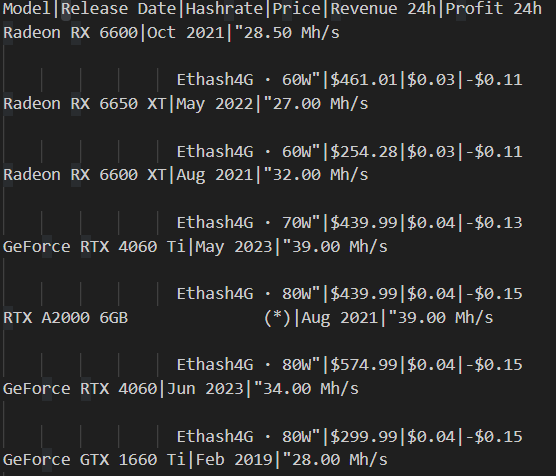


U nastavku sledi ponovljeni postupak formatiranja, transformacije podataka, procene nedostajućih vrednosti i analize korelacija između karakteristika grafičkih karti sa zaradom prilikom kopanja *Ethereum Classic* kriptovalute.

#### Reformatiranje i transformacija skupa podataka

In [29]:
df_mining = clean_mining_csv(f"{DATA_DIR}/mining-gpus-162-etc-etchash.csv")
df_mining

,Model,Hashrate,Revenue 24h
0,radeon rx 6600,28500000.0,0.03
1,radeon rx 6650 xt,27000000.0,0.03
2,radeon rx 6600 xt,32000000.0,0.04
3,geforce rtx 4060 ti,39000000.0,0.04
4,rtx a2000 6 gb,39000000.0,0.04
...,...,...,...
70,geforce rtx 3080 12 gb,101500000.0,0.11
71,radeon rx 7900 xt,83000000.0,0.09
72,geforce rtx 3090,119000000.0,0.13
73,geforce rtx 3080 ti,117000000.0,0.13


In [30]:
df_mining.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70 entries, 0 to 74
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Model        70 non-null     object 
 1   Hashrate     70 non-null     float64
 2   Revenue 24h  70 non-null     float64
dtypes: float64(2), object(1)
memory usage: 2.2+ KB


#### Analiza korelacije *hashrate*-a sa zaradom

In [31]:
pearson_corr, pearson_p = pearsonr(df_mining['Hashrate'], df_mining['Revenue 24h'])
print(f"Pirsonov koeficijent: {pearson_corr}. Relevantno obeležje: {pearson_p < 0.05}")

Pirsonov koeficijent: 0.9963486355224738. Relevantno obeležje: True


Opet zaključujemo da *hashrate* ima skoro savršenu linearnu korelaciju sa zaradom - ne razmatramo ga u daljoj analizi.

### Spajanje skupa podataka o grafičkim kartama sa podacima o zaradama, grupisanje specijalizovanih jezgara u jednu kolonu

In [32]:
df_mining = df_mining[['Model', 'Revenue 24h']]
df_merged = fuzzy_merge(df_mining, df_gpu, threshold=50)
df_merged

radeon rx 6600 <=> radeon rx 6600 (%: 100.0)
radeon rx 6650 xt <=> radeon rx 6650 xt (%: 100.0)
radeon rx 6600 xt <=> radeon rx 6600 xt (%: 100.0)
geforce rtx 4060 ti <=> geforce rtx 4060 ti (%: 100.0)
rtx a2000 6 gb <=> rtx a2000 6 gb (%: 100.0)
geforce rtx 4060 <=> geforce rtx 4060 (%: 100.0)
geforce gtx 1660 ti <=> geforce gtx 1660 ti (%: 100.0)
geforce rtx 3050 <=> geforce rtx 3050 (%: 100.0)
geforce gtx 1660 <=> geforce gtx 1660 (%: 100.0)
radeon rx 6750 xt <=> radeon rx 6750 xt (%: 100.0)
geforce gtx 1050 ti <=> geforce gtx 1050 ti (%: 100.0)
geforce gtx 1660 super <=> geforce gtx 1660 super (%: 100.0)
radeon rx 5500 xt <=> radeon rx 5500 xt (%: 100.0)
radeon rx 6700 xt <=> radeon rx 6700 xt (%: 100.0)
geforce gtx 1060 6 gb <=> geforce gtx 1060 6 gb (%: 100.0)
radeon rx 6800 xt <=> radeon rx 6800 xt (%: 100.0)
radeon rx 6800 <=> radeon rx 6800 (%: 100.0)
geforce rtx 4070 ti <=> geforce rtx 4070 ti (%: 100.0)
geforce rtx 3060 <=> geforce rtx 3060 (%: 100.0)
radeon rx 5600 xt <=> r

,Product Name,Base Clock,Boost Clock,Memory Clock,Memory Size,Memory Type,Memory Bus,Bandwidth,TDP,L1 Cache,L2 Cache,Shading Units,FP32 (float),Tensor Cores,Matrix Cores,Revenue 24h
0,firepro m3900,NaN,NaN,900.0,1024.0,GDDR3,64.0,14.40,20.0,8.0,128.0,160.0,240.0,NaN,NaN,NaN
1,firepro rg220,NaN,NaN,800.0,512.0,GDDR3,256.0,51.20,35.0,NaN,NaN,80.0,80.0,NaN,NaN,NaN
2,firepro rg220a,NaN,NaN,800.0,512.0,GDDR3,256.0,51.20,35.0,NaN,NaN,80.0,80.0,NaN,NaN,NaN
3,firestream 9350,NaN,NaN,1000.0,2048.0,GDDR5,256.0,128.00,150.0,8.0,512.0,1440.0,2016.0,NaN,NaN,NaN
4,firestream 9370,NaN,NaN,1150.0,4096.0,GDDR5,256.0,147.20,225.0,8.0,512.0,1600.0,2640.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1747,rtx pro 5000 blackwell,1590.0,2617.0,1750.0,49152.0,GDDR7,384.0,1372.16,300.0,128.0,98304.0,14080.0,73690.0,440.0,NaN,NaN
1748,rtx pro 6000 blackwell,1590.0,2617.0,1750.0,98304.0,GDDR7,512.0,1832.96,600.0,128.0,131072.0,24064.0,126000.0,752.0,NaN,NaN
1749,rtx pro 6000 blackwell max q,1590.0,2288.0,1750.0,98304.0,GDDR7,512.0,1832.96,300.0,128.0,131072.0,24064.0,110100.0,752.0,NaN,NaN
1750,rtx pro 6000 blackwell server,1590.0,2617.0,1750.0,98304.0,GDDR7,512.0,1832.96,600.0,128.0,131072.0,24064.0,126000.0,752.0,NaN,NaN


In [33]:
df_merged["AI Cores"] = df_merged.apply(get_ai_cores, axis=1)
df_merged = df_merged.drop(columns=["Tensor Cores", "Matrix Cores"], errors="ignore")
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product Name   1752 non-null   object 
 1   Base Clock     1091 non-null   float64
 2   Boost Clock    1091 non-null   float64
 3   Memory Clock   1569 non-null   float64
 4   Memory Size    1569 non-null   float64
 5   Memory Type    1752 non-null   object 
 6   Memory Bus     1569 non-null   float64
 7   Bandwidth      1569 non-null   float64
 8   TDP            1609 non-null   float64
 9   L1 Cache       1493 non-null   float64
 10  L2 Cache       1580 non-null   float64
 11  Shading Units  1746 non-null   float64
 12  FP32 (float)   1746 non-null   float64
 13  Revenue 24h    70 non-null     float64
 14  AI Cores       1752 non-null   float64
dtypes: float64(13), object(2)
memory usage: 205.4+ KB


#### Procena nedostajućih vrednosti (osim ciljnog obeležja zarade)

In [34]:
df_merged = impute_numeric_columns(df_merged)
df_merged.info()

Kolona: Base Clock -> RMSE: {'DecisionTree': np.float64(13.161772885675486), 'RandomForest': np.float64(11.95014961938803)}
Kolona: Boost Clock -> RMSE: {'DecisionTree': np.float64(14.997019236770738), 'RandomForest': np.float64(11.577964864120247)}
Kolona: Memory Clock -> RMSE: {'DecisionTree': np.float64(11.58027369799729), 'RandomForest': np.float64(10.175478297391265)}
Kolona: Memory Size -> RMSE: {'DecisionTree': np.float64(70.00234693125314), 'RandomForest': np.float64(66.53527026062048)}
Kolona: Memory Bus -> RMSE: {'DecisionTree': np.float64(4.845228390498942), 'RandomForest': np.float64(11.473764323817525)}
Kolona: Bandwidth -> RMSE: {'DecisionTree': np.float64(7.689297389458907), 'RandomForest': np.float64(9.459524408020544)}
Kolona: TDP -> RMSE: {'DecisionTree': np.float64(7.912468338580076), 'RandomForest': np.float64(6.435914510485754)}
Kolona: L1 Cache -> RMSE: {'DecisionTree': np.float64(3.791045743591963), 'RandomForest': np.float64(3.4649961293354994)}
Kolona: L2 Cache

#### Analiza korelacija između obeležja grafičkih karti sa ciljnim obeležjem zarade

In [35]:
numeric_res, categorical_res = analyze_influence(df_merged[df_merged['Revenue 24h'].notna()])
df_numeric_eth = pd.DataFrame(numeric_res)
df_categorical_eth = pd.DataFrame(categorical_res)
df_numeric_eth

,attribute,type,pearson_corr,pearson_p,spearman_corr,spearman_p
0,Bandwidth,numeric,0.945526,7.336548e-35,0.925325,2.386810e-30
1,Shading Units,numeric,0.911677,5.722453e-28,0.928639,5.388142e-31
2,TDP,numeric,0.864777,5.037040e-22,0.817484,5.954352e-18
3,FP32 (float),numeric,0.853825,5.894733e-21,0.904033,8.463276e-27
4,Memory Size,numeric,0.831436,5.086676e-19,0.831268,5.246557e-19
5,AI Cores,numeric,0.649664,1.167325e-09,0.576407,1.772723e-07
6,L2 Cache,numeric,0.573294,2.136694e-07,0.844940,3.760059e-20
7,L1 Cache,numeric,0.501850,9.599138e-06,0.611158,1.918892e-08
8,Boost Clock,numeric,0.347869,3.169176e-03,0.347136,3.237956e-03
9,Base Clock,numeric,0.282569,1.778342e-02,0.249032,3.762585e-02


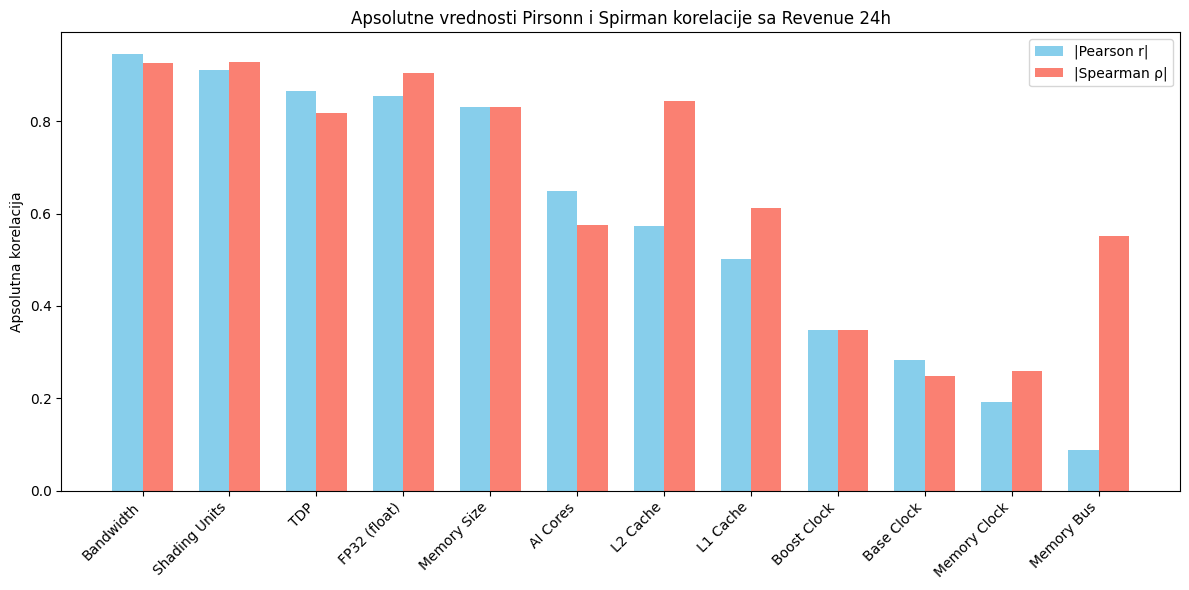

In [36]:
df_numeric_sorted = df_numeric_eth.sort_values(by='pearson_corr', key=abs, ascending=False)

plt.figure(figsize=(12,6))
bar_width = 0.35
index = range(len(df_numeric_sorted))

plt.bar(index, df_numeric_sorted['pearson_corr'].abs(), 
        bar_width, label='|Pearson r|', color='skyblue')

# Spearman barovi (pomereni udesno)
plt.bar([i + bar_width for i in index], df_numeric_sorted['spearman_corr'].abs(), 
        bar_width, label='|Spearman ρ|', color='salmon')

# Osa X i naslovi
plt.xticks([i + bar_width/2 for i in index], df_numeric_sorted['attribute'], rotation=45, ha='right')
plt.ylabel("Apsolutna korelacija")
plt.title("Apsolutne vrednosti Pirsonn i Spirman korelacije sa Revenue 24h")
plt.legend()
plt.tight_layout()
plt.show()

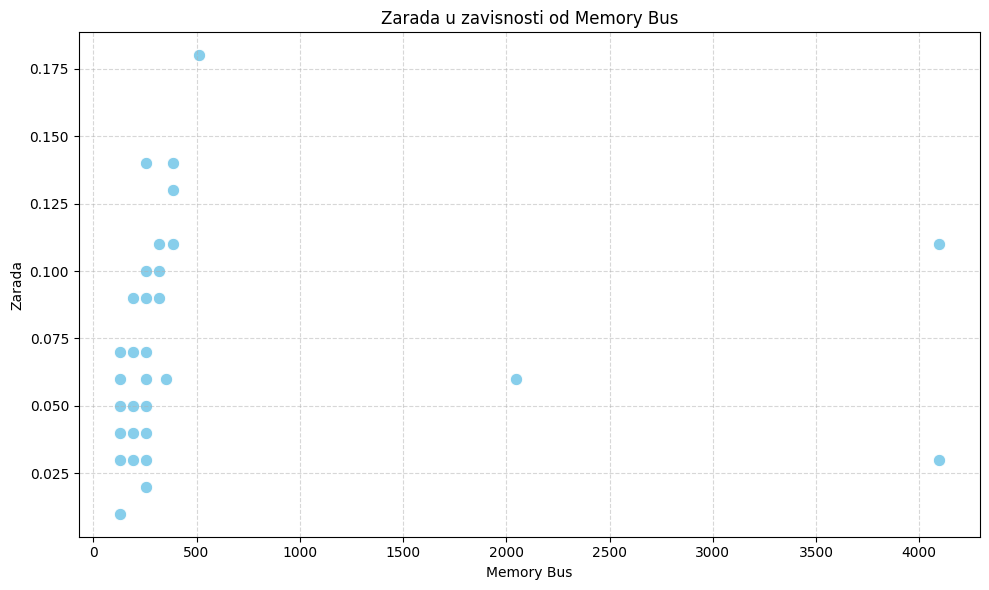

In [37]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df_merged, x='Memory Bus', y='Revenue 24h', color='skyblue', s=80)

plt.xlabel("Memory Bus")
plt.ylabel("Zarada")
plt.title("Zarada u zavisnosti od Memory Bus")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

*Memory Bus* pokazuje znatno veću, ali neliearnu korelaciju sa zaradom - ne sme se posmatrati sam za sebe.

Primećujemo da su u ovom slučaju ključne karakteristike grafičkih karti za kopanje *memory intensive* kriptovaluti *Bandwidth, Shading Units, TDP, FP32 (float)* i *Memory Size* atributi.

In [38]:
df_categorical_eth

,attribute,type,f_stat,p_value
0,Memory Type,categorical,14.029129,4.603139e-10


U ovom slučaju *Memory Type* ima još veći uticaj na zaradu, pošto je razlika između prosečnih zarada za svaki tip memorije još veća. Razmatraće se i ovo obeležje za predikciju zarade. 

In [39]:
df_merged, _, _ = predict_target(df_merged, ['TDP', 'Bandwidth', 'FP32 (float)', 'Memory Size', 'Shading Units', 'Memory Type'])
df_merged


Decision Tree:
Prosečan MAE  = 0.0084
Prosečan RMSE = 0.0128

Random Forest:
Prosečan MAE  = 0.0075
Prosečan RMSE = 0.0104
Odabrani algoritam za procenu ciljnog obeležja: Random Forest

Najmanja vrednost ciljnog obeležja: 0.0100
Najveća vrednost ciljnog obeležja: 0.1800


,Product Name,Base Clock,Boost Clock,Memory Clock,Memory Size,Memory Bus,Bandwidth,TDP,L1 Cache,L2 Cache,Shading Units,FP32 (float),Revenue 24h,AI Cores,Memory Type
0,firepro m3900,997.312083,993.915,900.0,1024.0,64.0,14.40,20.0,8.00,128.00,160.0,240.0,0.01830,0.0,GDDR3
1,firepro rg220,1046.243333,1083.235,800.0,512.0,256.0,51.20,35.0,22.56,57.92,80.0,80.0,0.01830,0.0,GDDR3
2,firepro rg220a,1046.243333,1083.235,800.0,512.0,256.0,51.20,35.0,22.56,57.92,80.0,80.0,0.01830,0.0,GDDR3
3,firestream 9350,1154.665000,1229.770,1000.0,2048.0,256.0,128.00,150.0,8.00,512.00,1440.0,2016.0,0.02135,0.0,GDDR5
4,firestream 9370,1148.370000,1229.180,1150.0,4096.0,256.0,147.20,225.0,8.00,512.00,1600.0,2640.0,0.01865,0.0,GDDR5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1747,rtx pro 5000 blackwell,1590.000000,2617.000,1750.0,49152.0,384.0,1372.16,300.0,128.00,98304.00,14080.0,73690.0,0.13475,440.0,GDDR7
1748,rtx pro 6000 blackwell,1590.000000,2617.000,1750.0,98304.0,512.0,1832.96,600.0,128.00,131072.00,24064.0,126000.0,0.16470,752.0,GDDR7
1749,rtx pro 6000 blackwell max q,1590.000000,2288.000,1750.0,98304.0,512.0,1832.96,300.0,128.00,131072.00,24064.0,110100.0,0.14630,752.0,GDDR7
1750,rtx pro 6000 blackwell server,1590.000000,2617.000,1750.0,98304.0,512.0,1832.96,600.0,128.00,131072.00,24064.0,126000.0,0.16470,752.0,GDDR7


Odabrani algoritam za predikciju cena u ovom slučaju je *Random Forest*. 

### Zaključak

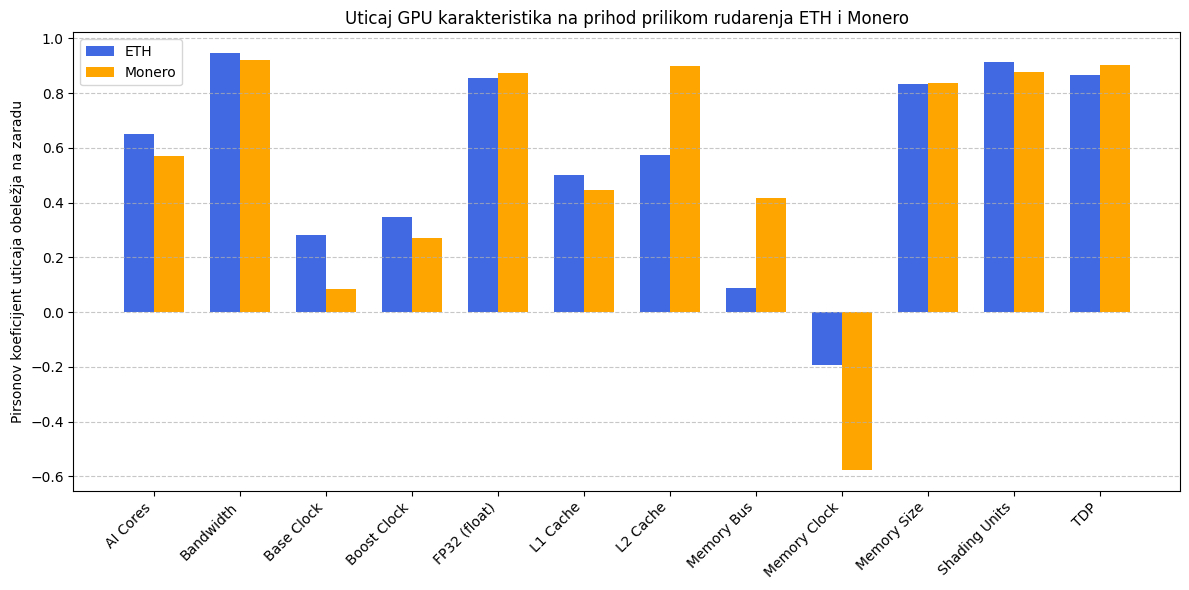

In [40]:
all_attributes = sorted(set(df_numeric_eth['attribute']).union(df_numeric_monero['attribute']))

# Napravi liste korelacija, ako atribut ne postoji u nekom DF-u stavi 0
eth_corrs = [df_numeric_eth.loc[df_numeric_eth['attribute']==a, 'pearson_corr'].values[0]
             if a in df_numeric_eth['attribute'].values else 0 for a in all_attributes]

monero_corrs = [df_numeric_monero.loc[df_numeric_monero['attribute']==a, 'pearson_corr'].values[0]
                if a in df_numeric_monero['attribute'].values else 0 for a in all_attributes]

x = np.arange(len(all_attributes))
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(x - width/2, eth_corrs, width, label='ETH', color='royalblue')
ax.bar(x + width/2, monero_corrs, width, label='Monero', color='orange')

ax.set_ylabel('Pirsonov koeficijent uticaja obeležja na zaradu')
ax.set_title('Uticaj GPU karakteristika na prihod prilikom rudarenja ETH i Monero')
ax.set_xticks(x)
ax.set_xticklabels(all_attributes, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Prema izvršenoj analizi je uočeno da postoji skup numeričkih karakteristika grafičkih karti koje su generalno bitne za zaradu prilikom kopanja kriptovalute: *Bandwidth, FP32 (float), Memory Size, Shading Units* i *TDP*. *Memory Type* je kategoričko obeležje koja je takođe generalno bitno za zaradu, pri čemu ima još veći uticaj na zaradu prilikom kopanja *memory intensive* kriptovalute - u ovom slučaju *Ethereum classic*. Takođe, uočeno je da veći *Memory clock* zapravo ne predstavlja prednost za kopanje kriptovaluti bilo kog tipa, samo ima negativniji uticaj na *core intensive* algoritme kopanja.  

## **DRUGI DEO**: Eksplorativna analiza uticaja karakteristika grafičkih karti na performanse AI treniranja
### UVOD
Cilj prvog dela ove analize je pronalazak ključnih karakteristika grafičkih karti koje utiču na performanse AI treniranja. Karakteristika koja opisuje koliko je neka grafička karta efikasna za obavljanje AI zadataka je ubrzanje tj. *Speedup*. Na osnovu analize će biti izdvojene najbitnije karakteristike grafičkih karti uz pomoć kojih će se izvršiti predikcija ubrzanja za sve ostale karte. <br>

### Skup podataka o ubrzanju grafičkih karti

In [41]:
df_ai = pd.read_csv(f"{DATA_DIR}/gpu-ai-specs-lambda.csv")
df_ai

,GPU Name,Speedup
0,LambdaCloud 1x GH200 96GB,5.93
1,LambdaCloud 1x H100 80GB SXM5,5.69
2,LambdaCloud 1x H100 80GB PCIe,3.81
3,A100 80GB SXM4,3.13
4,A100 80GB PCIe,2.99
5,LambdaCloud 1x A100 40GB PCIe,2.42
6,RTX 4090,2.06
7,RTX 6000 Ada,2.02
8,RTX A6000,1.49
9,RTX 3090,1.30


***Speedup*** je ubrzanje date grafičke karte u odnosu na CPU jedinicu tj. koliko je puta data karta brža za izvršavanje AI zadataka u odnosu na CPU.

***LambdaCloud*** je oznaka *cloud* okruženja u kojem je mereno ubrzanje pri treniranju AI modela i ne donosi nikakav doprinos ubrzanju - ovu oznaku je potrebno izbaciti. Kako bi se ovaj skup podataka spojio sa skupom podataka sa karakteristikama grafičkih karti, potrebno je normalizovati *GPU Name* istom metodom kao što je to urađeno i na skupu podataka sa karakteristikama grafičkih karti.

In [42]:
def clean_gpu_ai_specs_csv(df: pd.DataFrame) -> pd.DataFrame:
    df['GPU Name'] = df['GPU Name'].apply(clean_gpu_name)
    df['Speedup'] = df['Speedup'].apply(to_num)
    return df

In [43]:
df_ai = clean_gpu_ai_specs_csv(df_ai)
df_ai

,GPU Name,Speedup
0,gh200 96 gb,5.93
1,h100 80 gb sxm5,5.69
2,h100 80 gb pcie,3.81
3,a100 80 gb sxm4,3.13
4,a100 80 gb pcie,2.99
5,a100 40 gb pcie,2.42
6,rtx 4090,2.06
7,rtx 6000 ada,2.02
8,rtx a6000,1.49
9,rtx 3090,1.30


Potrebno je spojiti podatke o ubrzanju sa podacima o grafičkim kartama. Koristimo tehniku spajanja prema ključnim rečima - ukoliko postoje sve ključne reči iz imena grafičke karte iz AI skupa podataka u imenu karte u skupu podataka o karakteristikama karti, te dve instance se spajaju.

In [44]:
def keyword_merge(df_ai: pd.DataFrame, df_gpu: pd.DataFrame) -> pd.DataFrame:
    df_ai = df_ai.copy()
    df_gpu = df_gpu.copy()
    target_attr = "Speedup"

    df_gpu[target_attr] = pd.NA

    for _, ai_row in df_ai.iterrows():
        ai_name = ai_row["GPU Name"]
        ai_keywords = ai_name.split()

        for index, gpu_name in enumerate(df_gpu["Product Name"]):
            gpu_keywords = gpu_name.split()

            if all(word in gpu_keywords for word in ai_keywords):
                print(f"{ai_name} <=> {gpu_name}")
                df_gpu.at[index, target_attr] = ai_row[target_attr]
                break

    df_gpu[target_attr] = pd.to_numeric(df_gpu[target_attr], errors="coerce")
    return df_gpu

In [45]:
df_merged_ai = keyword_merge(df_ai, df_gpu)
df_merged_ai

h100 80 gb sxm5 <=> h100 sxm5 80 gb
h100 80 gb pcie <=> h100 pcie 80 gb
a100 80 gb sxm4 <=> a100 sxm4 80 gb
a100 80 gb pcie <=> a100 pcie 80 gb
a100 40 gb pcie <=> a100 pcie 40 gb
rtx 4090 <=> geforce rtx 4090
rtx 6000 ada <=> rtx 6000 ada generation
rtx a6000 <=> rtx a6000
rtx 3090 <=> geforce rtx 3090
v100 16 gb <=> tesla v100 pcie 16 gb
a10 <=> a10 pcie
quadro rtx 8000 <=> quadro rtx 8000


,Product Name,Base Clock,Boost Clock,Memory Clock,Memory Size,Memory Type,Memory Bus,Bandwidth,TDP,L1 Cache,L2 Cache,Shading Units,FP32 (float),Tensor Cores,Matrix Cores,Speedup
0,firepro m3900,NaN,NaN,900.0,1024.0,GDDR3,64.0,14.40,20.0,8.0,128.0,160.0,240.0,NaN,NaN,NaN
1,firepro rg220,NaN,NaN,800.0,512.0,GDDR3,256.0,51.20,35.0,NaN,NaN,80.0,80.0,NaN,NaN,NaN
2,firepro rg220a,NaN,NaN,800.0,512.0,GDDR3,256.0,51.20,35.0,NaN,NaN,80.0,80.0,NaN,NaN,NaN
3,firestream 9350,NaN,NaN,1000.0,2048.0,GDDR5,256.0,128.00,150.0,8.0,512.0,1440.0,2016.0,NaN,NaN,NaN
4,firestream 9370,NaN,NaN,1150.0,4096.0,GDDR5,256.0,147.20,225.0,8.0,512.0,1600.0,2640.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1747,rtx pro 5000 blackwell,1590.0,2617.0,1750.0,49152.0,GDDR7,384.0,1372.16,300.0,128.0,98304.0,14080.0,73690.0,440.0,NaN,NaN
1748,rtx pro 6000 blackwell,1590.0,2617.0,1750.0,98304.0,GDDR7,512.0,1832.96,600.0,128.0,131072.0,24064.0,126000.0,752.0,NaN,NaN
1749,rtx pro 6000 blackwell max q,1590.0,2288.0,1750.0,98304.0,GDDR7,512.0,1832.96,300.0,128.0,131072.0,24064.0,110100.0,752.0,NaN,NaN
1750,rtx pro 6000 blackwell server,1590.0,2617.0,1750.0,98304.0,GDDR7,512.0,1832.96,600.0,128.0,131072.0,24064.0,126000.0,752.0,NaN,NaN


In [46]:
df_merged_ai.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product Name   1752 non-null   object 
 1   Base Clock     1091 non-null   float64
 2   Boost Clock    1091 non-null   float64
 3   Memory Clock   1569 non-null   float64
 4   Memory Size    1569 non-null   float64
 5   Memory Type    1752 non-null   object 
 6   Memory Bus     1569 non-null   float64
 7   Bandwidth      1569 non-null   float64
 8   TDP            1609 non-null   float64
 9   L1 Cache       1493 non-null   float64
 10  L2 Cache       1580 non-null   float64
 11  Shading Units  1746 non-null   float64
 12  FP32 (float)   1746 non-null   float64
 13  Tensor Cores   286 non-null    float64
 14  Matrix Cores   19 non-null     float64
 15  Speedup        12 non-null     float64
dtypes: float64(14), object(2)
memory usage: 219.1+ KB


Može se primetiti da podaci o najperformantnijoj grafičkoj karti ne postoje u skupu podataka o karakteristikama grafičkih karti, ali to neće značajno uticati na analizu - sve ostale karte su uspešno spojene. <br>
Kao i u prethodnom delu, potrebno je ujediniti *Tensor Cores* i *Matrix Cores* u jednu kolonu *AI Cores*, kako se ne bi pravila razlika između proizvođača grafičkih karti. Pretpostavka da one karte koje nemaju popunjena ova polja nemaju specijalizovana jezgra za obavljanje AI zadataka važi i ovde.

In [47]:
df_merged_ai["AI Cores"] = df_merged_ai.apply(get_ai_cores, axis=1)
df_merged_ai = df_merged_ai.drop(columns=["Tensor Cores", "Matrix Cores"], errors="ignore")
df_merged_ai.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product Name   1752 non-null   object 
 1   Base Clock     1091 non-null   float64
 2   Boost Clock    1091 non-null   float64
 3   Memory Clock   1569 non-null   float64
 4   Memory Size    1569 non-null   float64
 5   Memory Type    1752 non-null   object 
 6   Memory Bus     1569 non-null   float64
 7   Bandwidth      1569 non-null   float64
 8   TDP            1609 non-null   float64
 9   L1 Cache       1493 non-null   float64
 10  L2 Cache       1580 non-null   float64
 11  Shading Units  1746 non-null   float64
 12  FP32 (float)   1746 non-null   float64
 13  Speedup        12 non-null     float64
 14  AI Cores       1752 non-null   float64
dtypes: float64(13), object(2)
memory usage: 205.4+ KB


Za dalju analizu uticaja karakteristika grafičkih karti na ubrzanje, potrebno je proceniti nedostajuće vrednosti svih obeležja osim ubrzanja. Primenjuje se ista tehnika kao i u prvom delu - ustanovljeno je da je *Random Forest* bolji algoritam prema RMSE grešci.

In [48]:
df_merged_ai = impute_numeric_columns(df_merged_ai, target_attr = "Speedup")
df_merged_ai.info()

Kolona: Base Clock -> RMSE: {'DecisionTree': np.float64(13.161772885675486), 'RandomForest': np.float64(11.95014961938803)}
Kolona: Boost Clock -> RMSE: {'DecisionTree': np.float64(14.997019236770738), 'RandomForest': np.float64(11.577964864120247)}
Kolona: Memory Clock -> RMSE: {'DecisionTree': np.float64(11.58027369799729), 'RandomForest': np.float64(10.175478297391265)}
Kolona: Memory Size -> RMSE: {'DecisionTree': np.float64(70.00234693125314), 'RandomForest': np.float64(66.53527026062048)}
Kolona: Memory Bus -> RMSE: {'DecisionTree': np.float64(4.845228390498942), 'RandomForest': np.float64(11.473764323817525)}
Kolona: Bandwidth -> RMSE: {'DecisionTree': np.float64(7.689297389458907), 'RandomForest': np.float64(9.459524408020544)}
Kolona: TDP -> RMSE: {'DecisionTree': np.float64(7.912468338580076), 'RandomForest': np.float64(6.435914510485754)}
Kolona: L1 Cache -> RMSE: {'DecisionTree': np.float64(3.791045743591963), 'RandomForest': np.float64(3.4649961293354994)}
Kolona: L2 Cache

Analiziraćemo linearnu korelaciju karakteristika grafičkih karti na ubrzanje.

In [49]:
df_merged_ai[df_merged_ai['Speedup'].notna()]

,Product Name,Base Clock,Boost Clock,Memory Clock,Memory Size,Memory Bus,Bandwidth,TDP,L1 Cache,L2 Cache,Shading Units,FP32 (float),Speedup,AI Cores,Memory Type
1384,tesla v100 pcie 16 gb,1245.0,1380.0,876.0,16384.0,4096.0,897.00,300.0,128.0,6144.0,5120.0,14130.0,1.00,640.0,HBM2
1423,quadro rtx 8000,1395.0,1770.0,1750.0,49152.0,384.0,672.00,260.0,64.0,6144.0,4608.0,16310.0,0.96,576.0,GDDR6
1486,a100 pcie 40 gb,765.0,1410.0,1215.0,40960.0,5120.0,1597.44,250.0,192.0,40960.0,6912.0,19490.0,2.42,432.0,HBM2e
1488,a100 sxm4 80 gb,1275.0,1410.0,1593.0,81920.0,5120.0,2088.96,400.0,192.0,40960.0,6912.0,19490.0,3.13,432.0,HBM2e
1517,geforce rtx 3090,1395.0,1695.0,1219.0,24576.0,384.0,936.20,350.0,128.0,6144.0,10496.0,35580.0,1.30,328.0,GDDR6X
1527,rtx a6000,1410.0,1800.0,2000.0,49152.0,384.0,768.00,300.0,128.0,6144.0,10752.0,38710.0,1.49,336.0,GDDR6
1531,a10 pcie,885.0,1695.0,1563.0,24576.0,384.0,600.20,150.0,128.0,6144.0,9216.0,31240.0,0.98,288.0,GDDR6
1532,a100 pcie 80 gb,1065.0,1410.0,1512.0,81920.0,5120.0,1986.56,300.0,192.0,81920.0,6912.0,19490.0,2.99,432.0,HBM2e
1634,geforce rtx 4090,2235.0,2520.0,1313.0,24576.0,384.0,1034.24,450.0,128.0,73728.0,16384.0,82580.0,2.06,512.0,GDDR6X
1635,h100 pcie 80 gb,1095.0,1755.0,1593.0,81920.0,5120.0,2088.96,350.0,256.0,51200.0,14592.0,51220.0,3.81,456.0,HBM2e


In [50]:
numeric_res_ai, categorical_res_ai = analyze_influence(df_merged_ai[df_merged_ai['Speedup'].notna()], target_col="Speedup")
df_numeric_ai = pd.DataFrame(numeric_res_ai)
df_categorical_ai = pd.DataFrame(categorical_res_ai)
df_numeric_ai

,attribute,type,pearson_corr,pearson_p,spearman_corr,spearman_p
0,Bandwidth,numeric,0.976310,5.647852e-08,0.970229,1.752001e-07
1,L1 Cache,numeric,0.900037,6.632463e-05,0.927437,1.401389e-05
2,Memory Size,numeric,0.789571,2.254562e-03,0.722403,7.963146e-03
3,TDP,numeric,0.788867,2.289622e-03,0.634703,2.661285e-02
4,Memory Bus,numeric,0.685371,1.389509e-02,0.789782,2.244174e-03
5,L2 Cache,numeric,0.492903,1.034858e-01,0.665988,1.805985e-02
6,Shading Units,numeric,0.464598,1.280810e-01,0.429588,1.633986e-01
7,FP32 (float),numeric,0.318423,3.131097e-01,0.380291,2.226734e-01
8,AI Cores,numeric,0.121924,7.058212e-01,0.007042,9.826702e-01
9,Base Clock,numeric,0.102609,7.509975e-01,0.073555,8.202845e-01


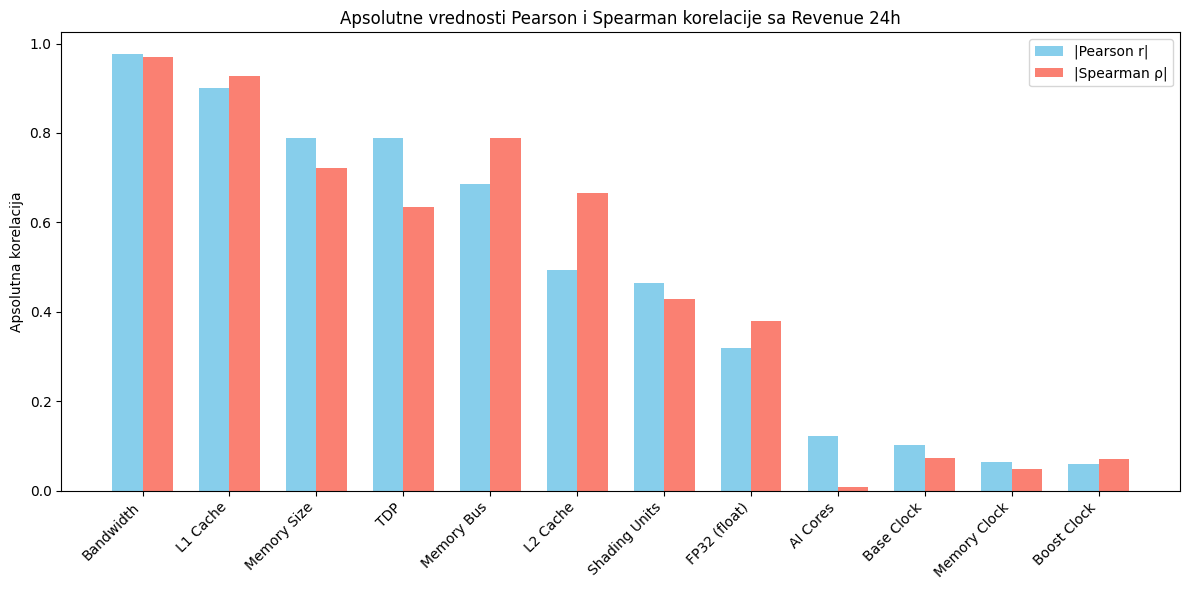

In [51]:
df_numeric_sorted = df_numeric_ai.sort_values(by='pearson_corr', key=abs, ascending=False)
plt.figure(figsize=(12,6))
bar_width = 0.35
index = range(len(df_numeric_sorted))

plt.bar(index, df_numeric_sorted['pearson_corr'].abs(), 
        bar_width, label='|Pearson r|', color='skyblue')

# Spearman barovi (pomereni udesno)
plt.bar([i + bar_width for i in index], df_numeric_sorted['spearman_corr'].abs(), 
        bar_width, label='|Spearman ρ|', color='salmon')

# Osa X i naslovi
plt.xticks([i + bar_width/2 for i in index], df_numeric_sorted['attribute'], rotation=45, ha='right')
plt.ylabel("Apsolutna korelacija")
plt.title("Apsolutne vrednosti Pearson i Spearman korelacije sa Revenue 24h")
plt.legend()
plt.tight_layout()
plt.show()

Uočena je zanimljiva činjenica - broj AI jezgara zapravo predstavlja **beznačajnu** karakteristiku za ubrzanje.

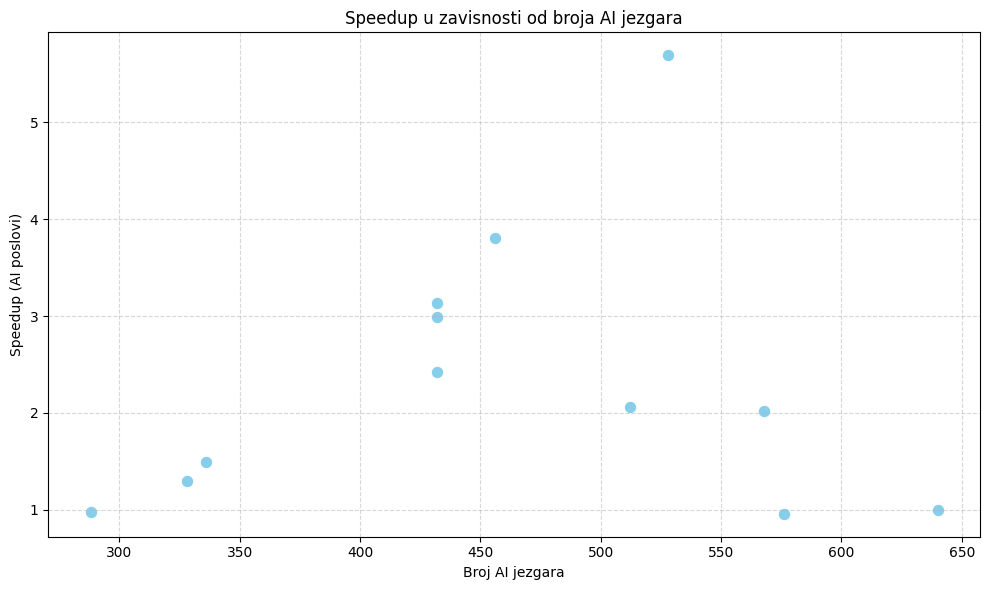

In [52]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df_merged_ai, x='AI Cores', y='Speedup', color='skyblue', s=80)

plt.xlabel("Broj AI jezgara")
plt.ylabel("Speedup (AI poslovi)")
plt.title("Speedup u zavisnosti od broja AI jezgara")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Ne postoji jasno definisana korelacija između broja AI jezgara i ostvarenog ubrzanja. Ovo je indikator činjenice da se ova karakteristika ne sme posmatrati izolovano, tj. da je potrebno razmatrati i ostale karakteristike grafičkih karti. Izdvojena numerička obeležja koje će se koristiti za predikciju ubrzanja su *Bandwidth*, *L1 Cache*, *Memory Size* i *TDP*.

In [53]:
df_categorical_ai

,attribute,type,f_stat,p_value
0,Memory Type,categorical,17.237607,0.000993


*Memory Type* predstavlja veliki uticaj na postignuto ubrzanje grafičke karte - i ovo obeležje će se uzeti u obzir prilikom predikcije ubrzanja.

In [54]:
df_merged_ai, _, _ = predict_target(df_merged_ai, ['TDP', 'Bandwidth', 'Memory Size', 'L1 Cache', 'Memory Type'], n_splits=12, target_col='Speedup')
df_merged_ai.info()


Decision Tree:
Prosečan MAE  = 0.6333
Prosečan RMSE = 0.6333

Random Forest:
Prosečan MAE  = 0.5405
Prosečan RMSE = 0.5405
Odabrani algoritam za procenu ciljnog obeležja: Random Forest

Najmanja vrednost ciljnog obeležja: 0.9600
Najveća vrednost ciljnog obeležja: 5.6900
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product Name   1752 non-null   object 
 1   Base Clock     1752 non-null   float64
 2   Boost Clock    1752 non-null   float64
 3   Memory Clock   1752 non-null   float64
 4   Memory Size    1752 non-null   float64
 5   Memory Bus     1752 non-null   float64
 6   Bandwidth      1752 non-null   float64
 7   TDP            1752 non-null   float64
 8   L1 Cache       1752 non-null   float64
 9   L2 Cache       1752 non-null   float64
 10  Shading Units  1752 non-null   float64
 11  FP32 (float)   1752 non-null   float64
 12  

U ovom slučaju, algoritam koji je korišćen za predikciju ubrzanja je *Random Forest*.

### Zaključak
Primećeno je da postoje generalne karakteristike koje imaju veliki uticaj kako na performantnost AI treniranja (čija jedinica je ubrzanje), tako i na zaradu prilikom kopanja kriptovaluti - to su *Bandwidth, Memory Size, Memory Type, i TDP*. *AI Cores* sami za sebe nisu od značaja za performantnost grafičke karte u kontekstu AI treniranja.

## **TREĆI DEO**: Timeseries analiza i predikcija cene grafičkih karti na osnovu spoljašnjih faktora kao što su cene kriptovaluta Monero, Ethereum Classic i trenda AI treniranja

### UVOD
Cilj ovog poglavlja je upoređivanje trenda cena grafičkih karti, navedenih kriptovaluta i aproksimiranog trenda AI treniranja, nakon čega će se, koristeći algoritme LSTM i ARIMA, na osnovu skupljenih podataka raditi predikcija cena grafičkih karti u odnosu na ove faktore. 
**NAPOMENA**: Istorijske cene grafičkih karti i kriptovaluta su zabeležene u valuti USD.

### Primer skupa podataka sa istorijskim cenama grafičkih karti

In [55]:
df_gpu_prices_example = pd.read_csv(f"{DATA_DIR}/price_data_dir/PNY_VCQRTX5000-PB_Quadro_RTX_5000_16_GB_Video_Card_(VCQRTX5000-PB)_-_PCPartPicker.csv")
df_gpu_prices_example

,date,price,gpu_name
0,2023-10-21,NaN,PNY VCQRTX5000-PB Quadro RTX 5000 16 GB Video ...
1,2023-10-22,1349.36,PNY VCQRTX5000-PB Quadro RTX 5000 16 GB Video ...
2,2023-10-23,1349.36,PNY VCQRTX5000-PB Quadro RTX 5000 16 GB Video ...
3,2023-10-24,1258.62,PNY VCQRTX5000-PB Quadro RTX 5000 16 GB Video ...
4,2023-10-25,1258.62,PNY VCQRTX5000-PB Quadro RTX 5000 16 GB Video ...
...,...,...,...
727,2025-10-17,1025.68,PNY VCQRTX5000-PB Quadro RTX 5000 16 GB Video ...
728,2025-10-18,1025.68,PNY VCQRTX5000-PB Quadro RTX 5000 16 GB Video ...
729,2025-10-19,1025.68,PNY VCQRTX5000-PB Quadro RTX 5000 16 GB Video ...
730,2025-10-20,1025.68,PNY VCQRTX5000-PB Quadro RTX 5000 16 GB Video ...


Cene grafičkih karti su scrape-ovane sa sajt-a [PC Part Picker](https://pcpartpicker.com/products/video-card/) polu automatizovanom metodom. S obzirom da je PC Part Picker zaštićen vodećim bot-protection mehanizmom koji pruža CloudFlare neka jednostavnija vrsta automatizacije nije bila moguća. Krajnje rešenje bilo je: s obzirom da su vrednosti grafika istorijskih cena enkodovane u script tag na html stranici, stranice su ručno skidane, a automatska skripta koja listenuje na promene fajlova u navedenom direktorijumu je u real-timeu parsirala podatke i pravila fajlove.

### Primer skupa podataka sa istorijskim cenama kriptovaluta

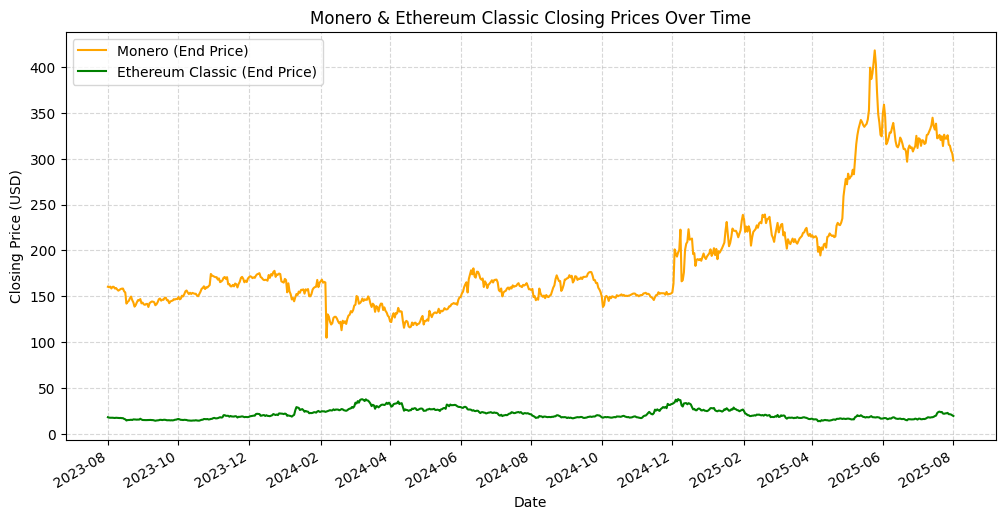

In [59]:
df_monero_prices = pd.read_csv(f"{DATA_DIR}/monero_2023-08-01_2025-08-01.csv")
df_monero_prices['date'] = pd.to_datetime(df_monero_prices[df_monero_prices.columns[0]])
df_monero_prices = df_monero_prices.set_index('date')
df_monero_prices

df_etc_prices = pd.read_csv(f"{DATA_DIR}/ethereum-classic_2023-08-01_2025-08-01.csv")
df_etc_prices['date'] = pd.to_datetime(df_etc_prices[df_etc_prices.columns[0]])
df_etc_prices = df_etc_prices.set_index('date')
df_etc_prices

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(df_monero_prices.index, df_monero_prices['Close'], color='orange', label='Monero (End Price)')
ax.plot(df_etc_prices.index, df_etc_prices['Close'], color='green', label='Ethereum Classic (End Price)')
ax.set_xlabel('Date')
ax.set_ylabel('Closing Price (USD)')
ax.set_title('Monero & Ethereum Classic Closing Prices Over Time')
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
fig.autofmt_xdate()

Istorijske cene za obe kriptovalute su prikupljene sa sajta [Coincodex](https://coincodex.com). U periodu kada su ovi podaci scrape-ovani ovo je jedini sajt koji smo uspeli da pronađemo da pruža ovakve podatke bez dodatnog troška. Bilo bi interesantno uporediti ove podatke sa nekim više proverenim skupom podataka sa popularnijih sajtova/API-a.

### Primer skupa podataka sa trendom AI treniranja

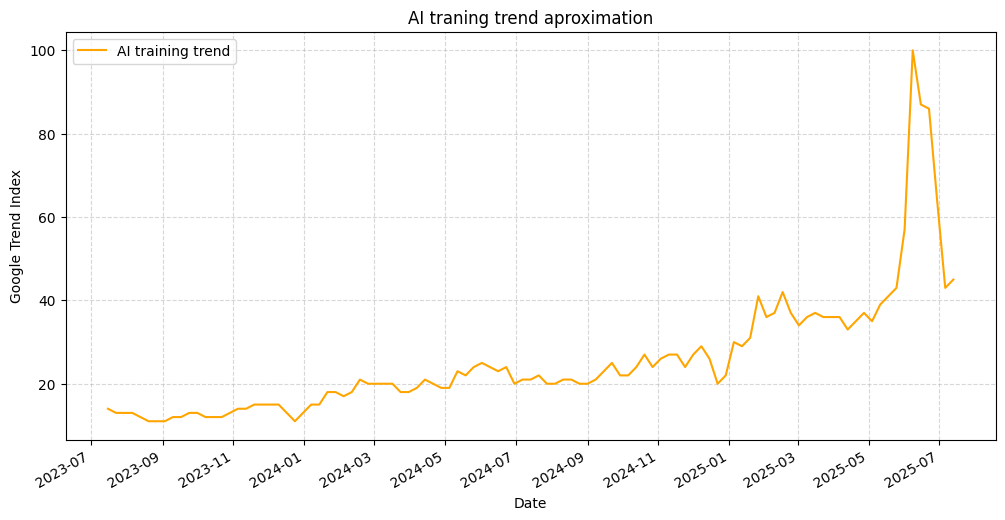

In [62]:
df_ai_training_trend = pd.read_csv(f"{DATA_DIR}/ai-trends-weekly.csv")
df_ai_training_trend['date'] = pd.to_datetime(df_ai_training_trend[df_ai_training_trend.columns[0]])
df_ai_training_trend = df_ai_training_trend.set_index('date')
df_ai_training_trend

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(df_ai_training_trend.index, df_ai_training_trend['ai_training'], color='orange', label='AI training trend')
ax.set_xlabel('Date')
ax.set_ylabel('Google Trend Index')
ax.set_title('AI traning trend aproximation')
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
fig.autofmt_xdate()

plt.show()

Podaci o trendu AI treniranja su aproksimirani na osnovu trenada search terma "ai training" na Google-ovom search enginu, na globalnom nivou. 

### Priprema podataka

Potrebno je udraditi nekoliko koraka kako bi timeseries podaci bili spremni za jednostavnu obradu:

1. Spojiti sve GPUs u jedan dataset
2. Indeksirati sve podatke po dateu
3. Alignovati podatke 

In [ ]:
GPU_FOLDER = 'data/price_data_dir'
MONERO_CSV = 'data/monero_2023-08-01_2025-08-01.csv'
ETC_CSV = 'data/ethereum-classic_2023-08-01_2025-08-01.csv'
AI_WEEKLY_CSV = 'data/ai-trends-weekly.csv'
OUTPUT_DIR = 'analysis/price-analysis'
LOOKBACK = 60
TEST_DAYS = 90
LSTM_EPOCHS = 100

# GPU data
gpu_files = sorted(glob.glob(os.path.join(GPU_FOLDER, '*.csv')))
dfs = []
for f in gpu_files:
    df = pd.read_csv(f)
    if 'date' not in df.columns:
        df.rename(columns={df.columns[0]:'date'}, inplace=True)
    if 'price' not in df.columns:
        df.rename(columns={df.columns[1]:'price'}, inplace=True)
    if 'gpu_name' not in df.columns:
        df['gpu_name'] = os.path.splitext(os.path.basename(f))[0]
    df['date'] = pd.to_datetime(df['date'])
    dfs.append(df[['date','gpu_name','price']])
gpus_tall = pd.concat(dfs, ignore_index=True)
gpus = gpus_tall.pivot_table(index='date', columns='gpu_name', values='price')

# Crypto prices data
def read_crypto_with_close_prices(path):
    df = pd.read_csv(path)
    end_col = [c for c in df.columns if 'close' in c.lower()][0]
    df['date'] = pd.to_datetime(df[df.columns[0]])
    df = df.set_index('date')
    return df[end_col].rename(path.split('/')[-1].split('.')[0])

monero = read_crypto_with_close_prices(MONERO_CSV).to_frame('monero')
etc = read_crypto_with_close_prices(ETC_CSV).to_frame('etc')

# AI training trend data
ai = pd.read_csv(AI_WEEKLY_CSV)
week_col = [c for c in ai.columns if 'week' in c.lower() or 'date' in c.lower()][0]
ai_col = [c for c in ai.columns if 'ai_training' in c.lower()][0]
ai[week_col] = pd.to_datetime(ai[week_col])
ai = ai.set_index(week_col)[ai_col].rename('ai')

# Align timeseries
start = min(monero.index.min(), etc.index.min(), gpus.index.min(), ai.index.min())
end = max(monero.index.max(), etc.index.max(), gpus.index.max(), ai.index.max())
all_days = pd.date_range(start, end, freq='D')
monero = monero.reindex(all_days).ffill().bfill()
etc = etc.reindex(all_days).ffill().bfill()
gpus = gpus.reindex(all_days).ffill().bfill()
ai_daily = ai.reindex(ai.index.union(all_days)).sort_index().resample('D').interpolate(method='time').reindex(all_days)

### Kreiranje featura

Pored featurea koji će biti izvučeni iz podataka o AI trendu i cenama kriptovaluta, dodajemo i **contextual features**.
Ovi feature-i prikazuju šire stanje (environment) u kojem postoje informacije o cenama GPU-ova. Cena GPU modela korelira u odnosu na njenu sopstvenu istoriju cena, ali korelira i sa celim stanjem tržišta. Na primer, na osnovu **contextual featurea** kao što su prosečna cena, medijan i standardna devijacija cene za sve modele tog dana možemo da vidimo kako se ostatak tržišta ponašao tog dana (da li su cene svih grafičkih u proseku skočile taj dan?).
Koršćenjem PCA (Principal component analysis) metode, redukujemo problem i smanjujemo noise koji može nastati iz istorijskih cena ~58 grafičkih karti. Principal komponente prikazuju zajedničke obrasce kretanja cena između različitih GPU modela.

In [ ]:
gpu_mean = gpus.mean(axis=1).rename('gpu_mean')
gpu_median = gpus.median(axis=1).rename('gpu_median')
gpu_std = gpus.std(axis=1).rename('gpu_std')
valid_cols = gpus.columns[gpus.isna().mean()<0.2]
if len(valid_cols)>=3:
    gpus_valid = gpus[valid_cols].fillna(method='ffill').fillna(method='bfill')
    scaler_for_pca = StandardScaler()
    gpus_scaled = scaler_for_pca.fit_transform(gpus_valid)
    pca = PCA(n_components=min(5, gpus_scaled.shape[1]))
    pcs = pca.fit_transform(gpus_scaled)
    gpu_pcs = pd.DataFrame(pcs, index=gpus_valid.index, columns=[f'pc{i+1}' for i in range(pcs.shape[1])])
else:
    gpu_pcs = pd.DataFrame(index=gpus.index)

features_base = pd.concat([monero,etc,ai_daily,gpu_mean,gpu_median,gpu_std,gpu_pcs], axis=1)

### Treniranje modela

U ovom delu se za svaki GPU treniraju modeli koji predviđaju njegovu cenu na osnovu istorijskih podataka.  
Koriste se dva pristupa: **ARIMA** (klasični statistički model za vremenske serije) i **LSTM** (neuronska mreža koja uči složene vremenske obrasce kroz vreme).

Pre treniranja, podaci se pripremaju dodavanjem **lag karakteristika** – to su prethodne vrednosti cene (na primer, cena od pre 1, 2, 7, 14 ili 30 dana).  
Na taj način modeli mogu da uče vremensku dinamiku, tj. kako prethodne cene utiču na buduće vrednosti.

Skup podataka se deli na trening (većina vremenske serije, koristi se za učenje modela) i test deo (poslednjih nekoliko dana, koristi se za proveru tačnosti modela).  
Pored osnovnog modela, treniraju se i dodatni modeli koji kao ulazne karakteristike koriste samo pojedinačne izvore podataka: cenu Monera, cenu Ethereuma i popularnost AI treninga, da bi se proverilo koliko svaka od ovih promenljivih samostalno doprinosi predviđanju cena GPU-ova.

Rezultati (RMSE i MAE) za svaki GPU i svaku varijantu modela se upisuju u CSV fajl radi dalje analize. Dodatno su izračunati i relativan RMSE i MAE koji prikazuju grešku modela u odnosu na prosečnu cenu. 

In [76]:
# Helpers
def evaluate(true, pred):
    return {'rmse': root_mean_squared_error(true, pred), 'mae': mean_absolute_error(true, pred)}

def fit_arima(train_y, train_exog=None):
    model = pm.auto_arima(train_y, exogenous=train_exog, seasonal=False, stepwise=True, suppress_warnings=True, max_p=5, max_q=5, max_d=2)
    order = model.order
    mod = sm.tsa.SARIMAX(train_y, exog=train_exog, order=order, enforce_stationarity=False, enforce_invertibility=False)
    res = mod.fit(disp=False)
    return res

def build_lstm(input_shape):
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

results = []
gpu_cols = gpus.columns.tolist()
for gpu in gpu_cols:
    try:
        df = pd.DataFrame({
            'price': gpus[gpu],
            'monero': monero['monero'],
            'etc': etc['etc'],
            'ai': ai_daily,
            'gpu_mean': gpu_mean
        })
        for c in gpu_pcs.columns if 'gpu_pcs' in globals() else []:
            df[c] = gpu_pcs[c]
        df = df.dropna()
        if len(df)<200: continue

        for lag in [1,2,3,7,14,30]:
            df[f'lag_{lag}'] = df['price'].shift(lag)
        df = df.dropna()

        train = df.iloc[:-TEST_DAYS]
        test = df.iloc[-TEST_DAYS:]

        # ARIMA
        exog_cols = [c for c in ['ai','gpu_mean','pc1','pc2','pc3'] if c in train.columns]
        try:
            ar_res = fit_arima(train['price'], train_exog=train[exog_cols] if exog_cols else None)
            ar_pred = ar_res.predict(start=test.index[0], end=test.index[-1], exog=test[exog_cols] if exog_cols else None)
            ar_eval = evaluate(test['price'], ar_pred)
        except:
            ar_eval={'rmse':np.nan,'mae':np.nan}; ar_pred=pd.Series(index=test.index,data=np.nan)

        # LSTM
        feature_cols=['price','ai','gpu_mean']+[c for c in ['pc1','pc2','pc3'] if c in df.columns]
        scaler = MinMaxScaler()
        scaler.fit(train[feature_cols])
        X = scaler.transform(df[feature_cols])
        y = df['price'].values
        def create_seq(X,y,lookback=LOOKBACK):
            Xs,ys=[],[]
            for i in range(lookback,len(X)):
                Xs.append(X[i-lookback:i]); ys.append(y[i])
            return np.array(Xs), np.array(ys)
        Xs,ys = create_seq(X,y)
        split = len(Xs)-TEST_DAYS
        Xtr,Xte = Xs[:split],Xs[split:]
        ytr,yte = ys[:split],ys[split:]
        model = build_lstm((Xtr.shape[1],Xtr.shape[2]))
        es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        model.fit(Xtr,ytr,epochs=LSTM_EPOCHS,batch_size=32,validation_split=0.1,callbacks=[es],verbose=0)
        lstm_pred = model.predict(Xte).ravel()
        lstm_eval = evaluate(yte,lstm_pred)

        # For single feature
        single_metrics = {}
        for feat_name, feat_cols in [('monero',['monero','gpu_mean']),
                                     ('eth',['etc','gpu_mean']),
                                     ('ai',['ai','gpu_mean'])]:
            
            try:
                arima_res = fit_arima(train['price'], train_exog=train[feat_cols])
                arima_pred = arima_res.predict(
                    start=test.index[0],
                    end=test.index[-1],
                    exog=test[feat_cols]
                )
                arima_eval = evaluate(test['price'], arima_pred)
                single_metrics[f'{feat_name}_arima_rmse'] = arima_eval['rmse']
                single_metrics[f'{feat_name}_arima_mae']  = arima_eval['mae']
            except Exception as e:
                single_metrics[f'{feat_name}_arima_rmse'] = np.nan
                single_metrics[f'{feat_name}_arima_mae']  = np.nan
            
            try:
                X_feat = df[feat_cols].values
                Xs_feat,ys_feat = create_seq(X_feat,y)
                Xtr_f,Xte_f = Xs_feat[:split],Xs_feat[split:]
                ytr_f,yte_f = ys_feat[:split],ys_feat[split:]
                model_f = build_lstm((Xtr_f.shape[1],Xtr_f.shape[2]))
                model_f.fit(Xtr_f,ytr_f,epochs=LSTM_EPOCHS,batch_size=32,validation_split=0.1,callbacks=[es],verbose=0)
                y_pred_f = model_f.predict(Xte_f).ravel()
                eval_f = evaluate(yte_f,y_pred_f)
                single_metrics[f'{feat_name}_rmse'] = eval_f['rmse']
                single_metrics[f'{feat_name}_mae'] = eval_f['mae']
            except:
                single_metrics[f'{feat_name}_rmse'] = np.nan
                single_metrics[f'{feat_name}_mae'] = np.nan

        results.append({
            'gpu':gpu,
            'arima_rmse':ar_eval['rmse'],
            'arima_mae':ar_eval['mae'],
            'lstm_rmse':lstm_eval['rmse'],
            'lstm_mae':lstm_eval['mae'],
            **single_metrics
        })
    
    except Exception as e:
        print('GPU error',gpu,e)

# Convert results to DataFrame
res_df = pd.DataFrame(results).sort_values('gpu')

# --- Compute relative RMSE/MAE for all models ---
for col in ['arima','lstm','monero','eth','ai']:
    res_df[f'{col}_rel_rmse'] = res_df.apply(lambda row: row[f'{col}_rmse'] / gpus[row['gpu']].mean(), axis=1)
    res_df[f'{col}_rel_mae']  = res_df.apply(lambda row: row[f'{col}_mae']  / gpus[row['gpu']].mean(), axis=1)

# Save final CSV
res_df.to_csv(os.path.join(OUTPUT_DIR,'gpu_model_results.csv'),index=False)
print('Done. Results saved to',os.path.join(OUTPUT_DIR,'gpu_model_results.csv'))


2025-10-27 22:15:36.447412: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7f024824f380> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
3/3 ━━━━━━━━━

### Rezultati

In [77]:
res_df

,gpu,arima_rmse,arima_mae,lstm_rmse,lstm_mae,monero_arima_rmse,monero_arima_mae,monero_rmse,monero_mae,eth_arima_rmse,...,arima_rel_rmse,arima_rel_mae,lstm_rel_rmse,lstm_rel_mae,monero_rel_rmse,monero_rel_mae,eth_rel_rmse,eth_rel_mae,ai_rel_rmse,ai_rel_mae
0,AMD 100-300000006 Radeon PRO W7700 16 GB Video...,10.072843,9.096750,12.420572,12.420572,2.086802,1.920961,992.877382,992.877382,2.242299,...,0.010165,0.009180,0.012534,0.012534,1.001979,1.001979,1.002195,1.002195,1.001700,1.001700
1,AMD 100-300000074 Radeon PRO W7900 48 GB Video...,63.948336,57.119766,64.979967,44.650302,62.924420,56.241279,3462.137332,3461.627954,62.943894,...,0.017161,0.015329,0.017438,0.011982,0.929110,0.928973,0.929164,0.929027,0.928894,0.928757
2,AMD 100-300000075 Radeon PRO W7800 32 GB Video...,23.194227,19.934543,4.953051,4.879454,11.704953,10.428897,2378.137838,2378.137517,11.858183,...,0.009580,0.008234,0.002046,0.002015,0.982255,0.982255,0.981964,0.981964,0.981948,0.981947
3,AMD 100-300000077 Radeon PRO W7600 8 GB Video ...,2.112492,1.750269,0.314811,0.314802,0.202424,0.183450,578.563469,578.563469,0.364237,...,0.003590,0.002974,0.000535,0.000535,0.983135,0.983135,0.981280,0.981280,0.981021,0.981021
4,AMD 100-300000078 Radeon PRO W7500 8 GB Video ...,3.379528,3.156730,3.164958,3.020249,3.740077,3.482567,423.467059,423.464864,3.764112,...,0.007869,0.007350,0.007369,0.007032,0.985985,0.985980,0.988611,0.988606,0.984501,0.984496
5,AMD 100-506095 Radeon Pro W5500 8 GB Video Car...,0.741764,0.683255,0.341026,0.341017,0.253868,0.234192,388.981003,388.980999,0.238455,...,0.001889,0.001740,0.000868,0.000868,0.990367,0.990367,0.989705,0.989705,0.988047,0.988047
6,AMD 100-506163 Radeon Pro VII 16 GB Video Card...,373.243777,329.904684,6.188799,6.188799,413.866326,381.946797,706.424753,706.424753,412.668562,...,0.422871,0.373769,0.007012,0.007012,0.800352,0.800352,0.799158,0.799158,0.799471,0.799471
7,AMD 100-506189 Radeon PRO W6400 4 GB Video Car...,26.903910,23.667169,26.329587,23.055665,26.275200,23.027793,251.757709,251.436036,26.339853,...,0.115632,0.101721,0.113164,0.099092,1.082045,1.080662,1.078092,1.076704,1.085142,1.083764
8,AMD 100-506208 Radeon PRO W6600 8 GB Video Car...,5.232343,4.902652,12.301954,12.301954,1.653152,1.526200,584.638174,584.638174,1.354875,...,0.009066,0.008494,0.021315,0.021315,1.012957,1.012957,1.010038,1.010038,1.009844,1.009844
9,Asus DUAL OC GeForce RTX 5050 8 GB Video Card ...,10.721854,6.139927,8.981798,8.405794,10.537678,5.654200,254.303870,254.146628,10.544337,...,0.041357,0.023683,0.034645,0.032423,0.980919,0.980313,0.982456,0.981850,0.976669,0.976059


In [80]:
rel_columns = [col for col in res_df.columns if 'rel_rmse' in col or 'rel_mae' in col]
averages = res_df[rel_columns].mean()
averages


arima_rel_rmse     0.045115
arima_rel_mae      0.039834
lstm_rel_rmse      0.053131
lstm_rel_mae       0.047493
monero_rel_rmse    1.003106
monero_rel_mae     1.002849
eth_rel_rmse       1.002882
eth_rel_mae        1.002624
ai_rel_rmse        1.002939
ai_rel_mae         1.002682
dtype: float64

Ako obratimo pažnju na relativne RMSE i MAE, primetno je da pri pokušaju predikcije samo na osnovu jednog trenda, bio to AI ili cene kriptovaluta, model jednostavno ne može nikako da da pogodi cenu sa prosečnim greškama od 100%. Sa druge strane kada se koriste svi trendovi i contextual featuri koje smo analizirali, model ima prosečne greške od između 4% i 5% što se može proceniti kao solidno u odnosu na to u kojem cenovnom rangu su određeni modeli (ako grafička košta 500$, 5% je 25$, ali ako košta 5000$ onda je greška 250$ što nije zanemarljivo).

Kod high-end modela, tržište je manje stabilno pa se kod njih i primećuju veće greške u predikciji za razliku od low-end modela.

### Zaključak

Primećena je drastična razlika u preciznosti modela (praktično da li model funkcioniše ili ne) koji su se trenirali samo sa individualnim feature-ima i modela koji je instreniran sa kombinacijom svih izvučenih feature-a. Ovo pokazuje da trend cena grafičkih karti ne može jednostavno biti koreliran sa trendom jedne kriptovalute ili popularnosti oblasti kao što je AI.